<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/9_Thunderstorm_prediction_count_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thunderstorm daily prediction per event

In [ ]:
! pip install optuna &> /dev/null

In [ ]:
!pip install -q "tabpfn>=8.0.8,<9" &> /dev/null

In [ ]:
import os
os.environ["TABPFN_TOKEN"] = ""

In [ ]:
# Set CUDA allocator for recycled GPU blocks.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'expandable_segments:True'

### Workspace

In [ ]:
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
import optuna
from itertools import combinations, product
import torch
import tabpfn
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf), ("torch", torch),
                     ("tabpfn", tabpfn),("optuna", optuna)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

print("CUDA device ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")


Libraries loaded:
  numpy          2.1.3
  pandas         2.2.3
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  torch          2.11.0+cu128
  tabpfn         8.5.0
  optuna         5.0.0
CUDA device  NVIDIA A100-SXM4-80GB


In [ ]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    'Tornado', 'High_Wind', 'Flooding', 'Winter_Storm',
       'Cold', 'Dust', 'Avalanche', 'Extreme_Heat', 'Coastal_Flood',
       'Wildfire', 'Drought', 'Tropical_Cyclone', 'Volcanic',
       'Geomagnetic', 'Marine_Other', 'Tsunami'
}


TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
    "INJURIES", "DEATHS",
]

PREDICTION_TARGETS = ["CASUALTY"]

ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = "EVENT_GROUP"

RANDOM_STATE = 0

DEFAULT_RANDOM_STATE = 0 # Set a random seed for reproducibility throughout Python, NumPy, and TensorFlow operations
random.seed(DEFAULT_RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(DEFAULT_RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(DEFAULT_RANDOM_STATE)
tf.random.set_seed(DEFAULT_RANDOM_STATE)

### Load data

In [ ]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_update_part_{i}.parquet" for i in range(1, 16)]

# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  57 columns
dtype backend in use:
float64    29
object     21
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_3,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,-0.052035,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,-0.037467,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,-0.087335,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,-0.057193,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,-0.104068,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,county-wide


## Workflow

### Building features

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    # prediction targets: direct + indirect
    out["INJURIES"] = out["INJURIES_DIRECT"] + out["INJURIES_INDIRECT"]
    out["DEATHS"] = out["DEATHS_DIRECT"] + out["DEATHS_INDIRECT"]
    out["CASUALTY"] = out["INJURIES"] + out["DEATHS"]


    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END",
        "TOR_F_SCALE", "TOR_WIDTH", "TOR_LENGTH","MONTH_NAME"
    ]
    drop_replaced_targets = [
            "INJURIES_DIRECT", "INJURIES_INDIRECT",
            "DEATHS_DIRECT", "DEATHS_INDIRECT",
            "DAMAGE_PROPERTY", "DAMAGE_CROPS",
            "INJURIES", "DEATHS",
        ]
    out = out.drop(columns=[column for column in drop_replaced_targets if column in out.columns])
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(1032841, 47)
1955-01-17 16:39:00 2025-12-28 23:13:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,SOURCE,MAGNITUDE,...,MONTH_BEGIN,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE,CASUALTY
Date,,,,,,,,,,,,,,,,,,,,,
1955-01-17 16:39:00,TEXAS,1955,Hail,C,227,HOWARD,FWD,CST,Unknown,0.75,...,1,1955,1,0.0,0.0,0.0,1.000000,0.0,1.0,0
1955-02-01 10:30:00,MISSOURI,1955,Hail,C,135,MONITEAU,SGF,CST,Unknown,0.75,...,2,1955,2,0.0,0.0,0.5,0.866025,0.0,1.0,0
1955-02-01 13:45:00,ARKANSAS,1955,Thunderstorm Wind,C,77,LEE,LZK,CST,Unknown,0.00,...,2,1955,2,0.0,0.0,0.5,0.866025,0.0,1.0,0
1955-02-05 08:00:00,LOUISIANA,1955,Thunderstorm Wind,C,89,ST. CHARLES,SHV,CST,Unknown,0.00,...,2,1955,2,0.0,0.0,0.5,0.866025,0.0,1.0,0
1955-02-11 16:00:00,VIRGINIA,1955,Thunderstorm Wind,C,175,SOUTHAMPTON,LWX,CST,Unknown,0.00,...,2,1955,2,0.0,0.0,0.5,0.866025,0.0,1.0,0


### Split first to avoid data-leakege

In [ ]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,970919,1955-01-17 16:39:00,2023-12-25 12:00:00
calibration,29990,2024-01-06 03:25:00,2024-12-31 23:20:00
test,31932,2025-01-01 00:50:00,2025-12-28 23:13:00


In [ ]:
########################################################
# Context features: what happened earlier the same day
#######################################################

# A hail report on a big outbreak day is not the same as an isolated one. For every
# event we summarise the thunderstorm events that **began strictly earlier on the same
# calendar day**, nationwide:

# `CTX_N_PREV_DAY`: how many events had already started that day;
# `CTX_N_STRONG_PREV_DAY`: how many of them were significant severe
#     (wind at least 65 knots, or hail at least 2 inches across);
# `CTX_MAX_WIND_PREV_DAY`: strongest wind gust so far that day, in knots (-1 = none yet);
# `CTX_MAX_HAIL_PREV_DAY`: largest hail so far that day, in inches (-1 = none yet);
# `CTX_N_WIND_PREV_DAY`: how many of the earlier events were wind reports;
# `CTX_N_HAIL_PREV_DAY`: how many of them were hail reports;
# `CTX_MINUTES_SINCE_STATE_TYPE`: minutes since the previous event of the same kind
#     in the same state (capped at 48 hours).

# ==============================================================================
# CONTEXT FEATURES FROM EARLIER EVENTS OF THE SAME DAY
# ==============================================================================

CONTEXT_COLUMNS = ["CTX_N_PREV_DAY", "CTX_N_STRONG_PREV_DAY",
                   "CTX_MAX_WIND_PREV_DAY", "CTX_MAX_HAIL_PREV_DAY",
                   "CTX_N_WIND_PREV_DAY", "CTX_N_HAIL_PREV_DAY",
                   "CTX_MINUTES_SINCE_STATE_TYPE"]
CONTEXT_MAX_MINUTES = 48.0 * 60.0
SIGNIFICANT_WIND_KNOTS = 65.0
SIGNIFICANT_HAIL_INCHES = 2.0
NO_EVENT_YET = -1.0


def magnitude_of(frame, event_type):
    """MAGNITUDE in its own unit, -1 on every row of another type.

    MAGNITUDE is knots for Thunderstorm Wind and inches for Hail, while Lightning
    and Heavy Rain carry a constant placeholder, so the two scales are kept apart."""
    values = frame["MAGNITUDE"].astype("float64").clip(lower=0)
    return values.where(frame["EVENT_TYPE"].eq(event_type), NO_EVENT_YET)


def add_context_features(frame):
    """Context from events that began strictly EARLIER on the same calendar day.

    Only predictors (X) of the earlier events are used, never their casualties.
    Called on one split at a time, so no information crosses split boundaries."""
    out = frame.copy()
    begin = pd.Series(out.index, index=out.index)
    day = begin.dt.normalize()

    wind = magnitude_of(out, "Thunderstorm Wind")
    hail = magnitude_of(out, "Hail")
    is_wind = out["EVENT_TYPE"].eq("Thunderstorm Wind").astype("float64")
    is_hail = out["EVENT_TYPE"].eq("Hail").astype("float64")
    strong = ((wind >= SIGNIFICANT_WIND_KNOTS) | (hail >= SIGNIFICANT_HAIL_INCHES)).astype("float64")

    keys = pd.DataFrame({"day": day.to_numpy(), "time": begin.to_numpy()}, index=out.index)

    def strictly_earlier(running_value):
        # events with the same start time keep the value of the first of them,
        # so simultaneous events do not count each other
        return running_value.groupby([keys["day"], keys["time"]]).transform("min")

    def running_count(flag):
        return strictly_earlier(flag.groupby(keys["day"]).cumsum() - flag)

    def running_max(value):
        # largest value among the rows before this one, -1 when the day has none yet
        so_far = value.groupby(keys["day"]).cummax()
        return strictly_earlier(so_far.groupby(keys["day"]).shift().fillna(NO_EVENT_YET))

    out["CTX_N_PREV_DAY"] = strictly_earlier(keys.groupby("day").cumcount().astype("float64"))
    out["CTX_N_STRONG_PREV_DAY"] = running_count(strong)
    out["CTX_N_WIND_PREV_DAY"] = running_count(is_wind)
    out["CTX_N_HAIL_PREV_DAY"] = running_count(is_hail)
    out["CTX_MAX_WIND_PREV_DAY"] = running_max(wind)
    out["CTX_MAX_HAIL_PREV_DAY"] = running_max(hail)

    previous_same_state_type = begin.groupby([out["STATE"], out["EVENT_TYPE"]]).shift()
    minutes = (begin - previous_same_state_type).dt.total_seconds() / 60.0
    out["CTX_MINUTES_SINCE_STATE_TYPE"] = (
        minutes.fillna(CONTEXT_MAX_MINUTES).clip(lower=0, upper=CONTEXT_MAX_MINUTES))

    # same transform the transformer applies through LOG_SCALAR
    context_log_columns = ["CTX_N_PREV_DAY", "CTX_N_STRONG_PREV_DAY",
                           "CTX_N_WIND_PREV_DAY", "CTX_N_HAIL_PREV_DAY",
                           "CTX_MINUTES_SINCE_STATE_TYPE"]
    out[context_log_columns] = np.log1p(out[context_log_columns])
    out[["DAY_DURATION", "DISTANCE"]] = np.log1p(out[["DAY_DURATION", "DISTANCE"]].clip(lower=0))
    return out


# one split at a time
train_raw = add_context_features(train_raw)
calibration_raw = add_context_features(calibration_raw)
test_raw = add_context_features(test_raw)

#display(train_raw[CONTEXT_COLUMNS].describe().round(2))

In [ ]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [ ]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(PREDICTION_TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in PREDICTION_TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: ['FLOOD_CAUSE', 'EVENT_GROUP']
Numerical zero-variance variables: []


In [ ]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"WFO","STATE","SOURCE","EVENT_GROUP"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME'] 


In [ ]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.80
PROTECTED_NUMERIC = set(PREDICTION_TARGETS) | {"EXPOSURE","MONTH_SIN"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'CTX_N_WIND_PREV_DAY', 'CTX_N_HAIL_PREV_DAY'] 


In [ ]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
     Numerical Categorical     tau_b  p_value  n_used    Assoc
          YEAR        risk  0.384402      0.0  970919 0.384402
      YEAR_END        risk  0.384402      0.0  970919 0.384402
    YEAR_BEGIN        risk  0.384402      0.0  970919 0.384402
ep_embedding_2        risk -0.373672      0.0  970919 0.373672
     MAGNITUDE        risk  0.257779      0.0  970919 0.257779
ep_embedding_4        risk -0.257180      0.0  970919 0.257180
ep_embedding_2 event_scope -0.249942      0.0  970919 0.249942
          YEAR event_scope  0.223670      0.0  970919 0.223670
      YEAR_END event_scope  0.223670      0.0  970919 0.223670
    YEAR_BEGIN event_scope  0.223670      0.0  970919 0.223670


In [ ]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"STATE","WFO","SOURCE","EVENT_GROUP"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical        H_Stat  p_value  n_used  k_groups   Eta_Sq
    YEAR_BEGIN CZ_TIMEZONE 742927.634922      0.0  970919        23 0.765175
      YEAR_END CZ_TIMEZONE 742927.634922      0.0  970919        23 0.765175
          YEAR CZ_TIMEZONE 742927.634922      0.0  970919        23 0.765175
ev_embedding_2  EVENT_TYPE 717326.429118      0.0  970919         4 0.738812
    YEAR_BEGIN DATA_SOURCE 683925.509564      0.0  970919         4 0.704410
          YEAR DATA_SOURCE 683925.509564      0.0  970919         4 0.704410
      YEAR_END DATA_SOURCE 683925.509564      0.0  970919         4 0.704410
ep_embedding_9     CZ_NAME 370632.177737      0.0  970919      2266 0.380288
ep_embedding_2 CZ_TIMEZONE 367865.405520      0.0  970919        23 0.378870
     MAGNITUDE  EVENT_TYPE 355446.550371      0.0  970919         4 0.366091


In [ ]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=200
PROTECTED = {"STATE","WFO","SOURCE","EVENT_GROUP"}
cat_cols = [c for c in train_raw.select_dtypes(include=['object', 'category', 'string']).columns if c not in PROTECTED]
cardinality = train_raw[cat_cols].nunique(dropna=False).sort_values(ascending=False)
cardinality_drop = cardinality[cardinality > HIGH_CARDINALITY].index.tolist()
print(cardinality)

CZ_NAME           2266
CZ_FIPS            375
CZ_TIMEZONE         23
MAGNITUDE_TYPE       6
DATA_SOURCE          4
EVENT_TYPE           4
event_scope          4
risk                 3
CZ_TYPE              2
FLOOD_CAUSE          1
dtype: int64


### Dataset filtered

In [ ]:
#feature_drop_columns = ['FLOOD_CAUSE', 'CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'CTX_N_WIND_PREV_DAY',
# 'CTX_N_HAIL_PREV_DAY', 'CZ_TIMEZONE', 'CZ_NAME', 'CZ_FIPS']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
feature_drop_columns = [c for c in feature_drop_columns if c != GROUP_COL]
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['FLOOD_CAUSE', 'CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'CTX_N_WIND_PREV_DAY', 'CTX_N_HAIL_PREV_DAY', 'CZ_TIMEZONE', 'CZ_NAME', 'CZ_FIPS']
Shapes after applying the frozen training filter:
(970919, 44) (29990, 44) (31932, 44)


In [ ]:
train_events.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 970919 entries, 1955-01-17 16:39:00 to 2023-12-25 12:00:00
Data columns (total 44 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   STATE                         970919 non-null  object 
 1   YEAR                          970919 non-null  int64  
 2   EVENT_TYPE                    970919 non-null  object 
 3   CZ_TYPE                       970919 non-null  object 
 4   WFO                           970919 non-null  object 
 5   SOURCE                        970919 non-null  object 
 6   MAGNITUDE                     970919 non-null  float64
 7   MAGNITUDE_TYPE                970919 non-null  object 
 8   DATA_SOURCE                   970919 non-null  object 
 9   EVENT_GROUP                   970919 non-null  object 
 10  ep_embedding_1                970919 non-null  float64
 11  ep_embedding_2                970919 non-null  float64
 12  ep_embeddi

In [ ]:
train_events.isnull().sum()/train_events.shape[0]*100

,0
STATE,0.0
YEAR,0.0
EVENT_TYPE,0.0
CZ_TYPE,0.0
WFO,0.0
SOURCE,0.0
MAGNITUDE,0.0
MAGNITUDE_TYPE,0.0
DATA_SOURCE,0.0
EVENT_GROUP,0.0


### Data Preparation

In [ ]:
#########################################
# Data Preparation shared by every model
#########################################

MODEL_SPECS = {
    "GLM": {
        "label": "Poisson GLM",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "fit_kind": "tabular",
        "default_params": {"alpha": 1.0},
    },
    "LGBM": {
        "label": "LightGBM Poisson",
        "nominal_encoding": "category",
        "scale_numeric": False,
        "fit_kind": "tabular",
        "default_params": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 200,
            "min_child_weight": 1e-2,
            "subsample": 0.8,
            "subsample_freq": 1,
            "colsample_bytree": 0.8,
            "reg_lambda": 5.0,
            "poisson_max_delta_step": 0.3,
        },
    },
    "LSTM": {
        "label": "LSTM Poisson",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "fit_kind": "sequence",
        "default_params": {
            "sequence_length": 6,
            "sequence_by": GROUP_COL,
            "units": 32,
            "dropout": 0.1,
            "learning_rate": 1e-3,
            "epochs": 5,
            "batch_size": 512,
            "verbose": 0,
        },
    },
}

DEFAULT_MODEL = "GLM"


def model_label(model=DEFAULT_MODEL):
    """returns the human-readable label from that model's spec."""
    return MODEL_SPECS[model]["label"]


def normalize_params(params, model=DEFAULT_MODEL):
    """merges user-supplied params over the model's default params;
    a bare number is read as the GLM's alpha"""
    if not isinstance(params, dict):
        params = {} if params is None else {"alpha": params}
    return {**MODEL_SPECS[model]["default_params"], **params}


def fit_nominal_encoder(train_df, model=DEFAULT_MODEL):
    """Encode the unranked categorical predictors, training split only.

    GLM, LSTM  -> one-hot encoding, unseen levels ignored.
    LGBM -> pandas `category` columns with the training levels frozen.

    EVENT_GROUP and the ordinals are left out: the first is a diagnostic key,
    the second keep their order inside a single column.

    Returns a dictionary describing the fitted encoding, read back by
    apply_nominal_encoder and build_model_matrices.
    """
    encoding = MODEL_SPECS[model]["nominal_encoding"]
    columns = [
        column
        for column in train_df.select_dtypes(
            include=["object", "string", "category"]
        ).columns
        if column not in ORDINAL_LEVELS and column != GROUP_COL
    ]
    frame = train_df[columns].astype(str)
    onehot = (
        OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(frame)
        if encoding == "onehot"
        else None
    )

    return {
        "model": model,
        "encoding": encoding,
        "columns": columns,
        "output_columns": (
            list(onehot.get_feature_names_out()) if onehot is not None else list(columns)
        ),
        "onehot": onehot,
        "categories": (
            {}
            if onehot is not None
            else {
                column: pd.CategoricalDtype(np.unique(frame[column]))
                for column in columns
            }
        ),
    }


def apply_nominal_encoder(data, encoder):
    """Replace the nominal columns with their encoded version."""
    frame = data[encoder["columns"]].astype(str)
    encoded = data.drop(columns=encoder["columns"])

    if encoder["encoding"] == "onehot":
        encoded[encoder["output_columns"]] = encoder["onehot"].transform(frame)
    else:
        for column, dtype in encoder["categories"].items():
            encoded[column] = frame[column].astype(dtype)

    return encoded


def categorical_columns(frame):
    return [
        column
        for column in frame.columns
        if isinstance(frame[column].dtype, pd.CategoricalDtype)
    ]


def prepare_target_data(df, target, encoder):
    """Model matrix for a single target, indexed by event date."""
    event_group = df[GROUP_COL].astype(str).to_numpy()
    other_targets = [c for c in TARGETS if c != target and c in df.columns]
    data = df.drop(columns=[GROUP_COL] + other_targets)

    for column, levels in ORDINAL_LEVELS.items():
        if column in data.columns:
            data[column] = data[column].map(
                {level: rank for rank, level in enumerate(levels)}
            )

    data = apply_nominal_encoder(data, encoder)
    data.insert(0, GROUP_COL, event_group)

    # categorical columns are left out of the inf replacement: replace() on
    numeric_columns = [c for c in data.columns if c not in categorical_columns(data)]
    data[numeric_columns] = data[numeric_columns].replace([np.inf, -np.inf], np.nan)
    data = data.dropna(subset=numeric_columns)

    return data.sort_index(kind="stable")


def build_model_matrices(frames, target, model=DEFAULT_MODEL):
    """Raw split frames -> everything an estimator needs, whatever the model.

    The first split is the fit split: the nominal encoder and, for the models
    that need it, the StandardScaler on the continuous and ordinal predictors
    are fitted on it alone and applied to every split.
    """
    fit_name = next(iter(frames))

    encoder = fit_nominal_encoder(frames[fit_name], model=model)
    prepared = {
        name: prepare_target_data(frame, target, encoder)
        for name, frame in frames.items()
    }

    feature_columns = [
        column
        for column in prepared[fit_name].columns
        if column not in [target, "EXPOSURE", GROUP_COL]
    ]
    category_columns = categorical_columns(prepared[fit_name])
    X = {
        name: frame.loc[:, feature_columns].astype(
            {c: np.float64 for c in feature_columns if c not in category_columns}
        )
        for name, frame in prepared.items()
    }

    scaler = None
    if MODEL_SPECS[model]["scale_numeric"]:
        dummy_columns = set(encoder["output_columns"])
        scaled_columns = [c for c in feature_columns if c not in dummy_columns]
        scaler = StandardScaler().fit(X[fit_name][scaled_columns])
        for matrix in X.values():
            matrix[scaled_columns] = scaler.transform(matrix[scaled_columns])

    return {
        "model": model,
        "prepared": prepared,
        "feature_columns": feature_columns,
        "encoder": encoder,
        "scaler": scaler,
        "X": X,
        "y": {
            name: frame[target].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
        "exposure": {
            name: frame["EXPOSURE"].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
    }


def build_sequence_index(groups, sequence_length):
    """Row positions of the window of events ending at each row.
    Returns an (n_rows, sequence_length) array of positions, oldest first. The
    window only walks back inside the same group.
    """
    groups = np.asarray(groups)
    index = np.empty((len(groups), sequence_length), dtype="int64")
    offsets = np.arange(sequence_length - 1, -1, -1)

    for _, block in pd.Series(np.arange(len(groups))).groupby(groups, sort=False):
        block = block.to_numpy()
        walk_back = np.arange(len(block))[:, None] - offsets[None, :]
        index[block] = block[np.clip(walk_back, 0, None)]

    return index


def sequence_batches(X_values, index, batch_size, y=None, weight=None):
    """Batches of (rows, sequence_length, features).
    With `y` and `weight`: shuffled training triples. Without: prediction inputs.
    """
    features = tf.constant(np.asarray(X_values, dtype="float32"))

    if y is None:
        dataset = (
            tf.data.Dataset.from_tensor_slices(index)
            .batch(batch_size)
            .map(lambda i: tf.gather(features, i))
        )
    else:
        dataset = (
            tf.data.Dataset.from_tensor_slices((
                index,
                np.asarray(y, dtype="float32"),
                np.asarray(weight, dtype="float32"),
            ))
            .shuffle(min(len(index), 100_000), seed=RANDOM_STATE)
            .batch(batch_size)
            .map(lambda i, t, w: (tf.gather(features, i), t, w))
        )

    return dataset.prefetch(tf.data.AUTOTUNE)


def fit_predict_tabular(matrices, params, fit_on, model):
    """One row in, one prediction out: the GLM and LightGBM path."""
    if model == "GLM":
        estimator = PoissonRegressor(fit_intercept=True, **params)
    else:
        estimator = LGBMRegressor(
            objective="poisson",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **params,
        )

    estimator.fit(
        matrices["X"][fit_on],
        matrices["y"][fit_on] / matrices["exposure"][fit_on],
        sample_weight=matrices["exposure"][fit_on],
    )

    predicted = {
        name: estimator.predict(X) * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return estimator, predicted


def fit_predict_sequence(matrices, params, fit_on, model):
    """A window of past events in, one prediction per event out: the LSTM path.
    One recurrent layer over the event window, log link on the output.
    """
    index = {
        name: build_sequence_index(frame[params["sequence_by"]], params["sequence_length"])
        for name, frame in matrices["prepared"].items()
    }

    rate = matrices["y"][fit_on] / matrices["exposure"][fit_on]

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    network = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(params["sequence_length"], matrices["X"][fit_on].shape[1])
        ),
        tf.keras.layers.LSTM(params["units"], dropout=params["dropout"]),
        tf.keras.layers.Dense(
            1,
            activation="exponential",
            bias_initializer=tf.keras.initializers.Constant(
                float(np.log(max(rate.mean(), 1e-6)))
            ),
        ),
    ])
    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss=tf.keras.losses.Poisson(),
    )
    network.fit(
        sequence_batches(
            matrices["X"][fit_on].to_numpy(),
            index[fit_on],
            params["batch_size"],
            y=rate,
            weight=matrices["exposure"][fit_on],
        ),
        epochs=params["epochs"],
        verbose=params["verbose"],
    )

    predicted = {
        name: network.predict(
            sequence_batches(X.to_numpy(), index[name], params["batch_size"]),
            verbose=0,
        ).ravel() * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return network, predicted


def fit_predict(matrices, params=None):
    """Fit on the first split, predict counts on all of them."""
    model = matrices["model"]
    fit_on = next(iter(matrices["X"]))
    params = normalize_params(params, model)

    kind = MODEL_SPECS[model]["fit_kind"]

    if kind == "sequence":
        return fit_predict_sequence(matrices, params, fit_on, model)
    if kind == "foundation":
        return fit_predict_foundation(matrices, params, fit_on, model)

    return fit_predict_tabular(matrices, params, fit_on, model)

### Hyperparameter Tuning by Expanding-Window Cross-Validation

In [ ]:
####################################
# Evaluation Metrics
####################################
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float),1e-6, None)

    n = len(y_true)

    null_deviance_is_zero = (n < 2 or np.allclose(y_true, y_true.mean()))


    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if null_deviance_is_zero else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


In [ ]:
#############################################################
# FINE TUNING BY EXPANDING-YEAR CROSS VALIDATION
#############################################################

VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(df, validation_years=VALIDATION_YEARS):
    """Yields expanding-window train/validation index splits, training
    on all years before each val_year and validating on that year alone."""
    years = df.index.year.to_numpy()

    for fold, val_year in enumerate(validation_years, start=1):
        train_index = np.flatnonzero(years < val_year)
        val_index = np.flatnonzero(years == val_year)

        if len(train_index) == 0 or len(val_index) == 0:
            continue

        yield fold, val_year, train_index, val_index


def suggest_params(trial, model=DEFAULT_MODEL):
    """Search space, one branch per model."""
    if model == "GLM":
        return {"alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)}

    if model == "LGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 100, 1000, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 50.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "poisson_max_delta_step": trial.suggest_float("poisson_max_delta_step", 0.05, 0.7, log=True),
        }

    if model == "LSTM":
        return {
            "sequence_length": trial.suggest_int("sequence_length", 3, 12),
            "units": trial.suggest_categorical("units", [16, 32, 64]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.3),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "epochs": trial.suggest_int("epochs", 3, 10),
            "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        }

    raise KeyError(f"no search space defined for {model!r}")


def tune_params_cv(
    train_df,
    target,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """Runs an Optuna hyperparameter search
    over expanding-window CV folds, minimizing mean Poisson deviance,
    and returns the best-found parameters normalized against
    the model's defaults."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Precompute model matrices for all folds (faster CV solution)
    print(f"Precomputing {len(validation_years)} folds for {target}...")
    fold_matrices = []
    for _, _, train_index, val_index in expanding_year_splits(train_df, validation_years):
        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target,
            model=model,
        )
        fold_matrices.append(matrices)

    def objective(trial):
        params = suggest_params(trial, model)
        scores = []
        try:
            for matrices in fold_matrices:
                _, predicted = fit_predict(matrices, params)
                scores.append(
                    mean_poisson_deviance(
                        matrices["y"]["validation"],
                        np.clip(predicted["validation"], 1e-6, None),
                    )
                )

                del predicted
            gc.collect()
            return float(np.mean(scores))
        except (ValueError, lightgbm.basic.LightGBMError) as e:
            gc.collect()
            raise optuna.exceptions.TrialPruned(f"Pruned due to numerical instability: {e}")

            #return float(np.mean(scores))
        #except ValueError as e:
            #raise optuna.exceptions.TrialPruned(f"Pruned due to numerical instability: {e}")

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, n_jobs=1)

    return normalize_params(study.best_params, model)


def find_best_parameters_for_all_targets(
    train_df,
    targets,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """One tuned parameter dictionary per target, for the requested model."""
    best_parameters = {}

    for target in targets:
        print(f"Tuning {model_label(model)} for target {target}...")

        best_parameters[target] = tune_params_cv(
            train_df=train_df,
            target=target,
            model=model,
            validation_years=validation_years,
            n_trials=n_trials,
        )

        print(f"  best parameters: {best_parameters[target]}")
        gc.collect()

    return best_parameters

### Fit the model

In [ ]:
###########################################
# Adaptive Conformal Prediction
###########################################

CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def build_daily_base(predictions, group_column=GROUP_COL, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits.

    With `group_name`, rows of the other groups count as zero so the calendar
    still spans the whole split."""
    daily_base = {}

    for split in ("calibration", "test"):
        split_mask = predictions["split"].eq(split)
        split_data = predictions.loc[split_mask, ["actual", "predicted"]].copy()

        if group_name is not None:
            other_groups = predictions.loc[split_mask, group_column].ne(group_name).to_numpy()
            split_data.loc[other_groups] = 0.0

        daily_base[split] = split_data.resample("D").sum()

    return daily_base


def conformalize_base(daily_base, freq="D", alpha_target=0.10, gamma=0.01):
    """Adaptive conformal intervals on the daily base, re-aggregated to the
    `freq` view.

    Conformity scores are the Poisson-standardized absolute residuals of the
    calibration base, summed over a rolling window as wide as the view will be
    read at: the window is what makes the monthly view usable.

    On the test view, alpha is updated after each period from whether that
    period was covered."""
    calibration = (
        daily_base["calibration"]
        .rolling(CALIBRATION_WINDOW_DAYS[freq])
        .sum()
        .dropna()
    )
    calibration_actual = calibration["actual"].to_numpy(dtype=float)
    calibration_predicted = calibration["predicted"].to_numpy(dtype=float)
    scores = np.sort(
        np.abs(calibration_actual - calibration_predicted)
        / np.sqrt(np.clip(calibration_predicted, 1, None))
    )
    n_scores = len(scores)

    test = daily_base["test"].resample(freq).sum()
    actual = test["actual"].to_numpy(dtype=float)
    predicted = test["predicted"].to_numpy(dtype=float)
    scale = np.sqrt(np.clip(predicted, 1, None))

    lower = np.empty(len(test))
    upper = np.empty(len(test))
    covered = np.empty(len(test), dtype=bool)
    alphas = np.empty(len(test))

    min_alpha = max(1e-3, 1.0 / (n_scores + 1))
    alpha_t = alpha_target

    for i in range(len(test)):
        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))

        # finite-sample-corrected (1 - alpha_t) quantile of the calibration scores
        rank = min(int(np.ceil((n_scores + 1) * (1.0 - alpha_t))), n_scores)
        margin = scores[rank - 1] * scale[i]

        lower[i] = max(0.0, predicted[i] - margin)
        upper[i] = predicted[i] + margin
        covered[i] = lower[i] <= actual[i] <= upper[i]
        alphas[i] = alpha_t

        alpha_t += gamma * (alpha_target - (1.0 - float(covered[i])))

    return test.assign(
        lower=lower,
        upper=upper,
        width=upper - lower,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
):
    """One monthly conformal frame per event group, keyed by group name."""
    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].unique():
        monthly = conformalize_base(
            build_daily_base(predictions, group_column, group_name),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal

In [ ]:
###################################
# Fit one model per target
###################################

SPLIT_ORDER = ["train", "calibration", "test"]


def build_forecast_results(
    train_df,
    calibration_df,
    test_df,
    targets,
    best_params,
    model=DEFAULT_MODEL,
    alpha_target=0.10,
    gamma=0.01,
    group_column=GROUP_COL):

    """Fits one model per outcome in targets, end-to-end: builds matrices,
    trains/predicts, computes overall and per-group metrics, and produces
    record-level plus daily/monthly aggregated conformal prediction intervals.
    Returns one result dict per target, keyed by target."""
    results = {}

    for target in targets:
        print(f"[{model_label(model)}] fitting {target}...")

        matrices = build_model_matrices(
            {"train": train_df, "calibration": calibration_df, "test": test_df},
            target,
            model=model)

        data = matrices["prepared"]
        y = matrices["y"]
        params = normalize_params(best_params.get(target), model)

        estimator, predicted = fit_predict(matrices, params)

        blocks = {
            name: pd.DataFrame(
                {"split": name,
                 "actual": y[name],
                 "predicted": predicted[name],
                 group_column: frame[group_column].to_numpy()},
                index=frame.index)
            for name, frame in data.items()
        }

        predictions = pd.concat(blocks.values()).sort_index(kind="stable")

        metrics = pd.DataFrame([{"split": name, **compute_metrics(y[name], predicted[name])}
                for name in data]).set_index("split")

        group_metrics = pd.DataFrame([
            {"split": name, group_column: group_name, **compute_metrics(part["actual"], part["predicted"])}
            for name, block in blocks.items()
            for group_name, part in block.groupby(group_column)
        ]).set_index(["split", group_column])

        daily_base = build_daily_base(predictions)

        results[target] = {
            "model": estimator,
            "model_name": model,
            "params": params,
            "metrics": metrics,
            "group_metrics": group_metrics,
            "predictions": predictions,
            "daily_conformal": conformalize_base(
                daily_base, freq="D", alpha_target=alpha_target, gamma=gamma),
            "monthly_conformal": conformalize_base(
                daily_base, freq="MS", alpha_target=alpha_target, gamma=gamma),
            "group_monthly_conformal": build_group_monthly_conformal(
                predictions, group_column=group_column, alpha_target=alpha_target, gamma=gamma),
            "feature_columns": matrices["feature_columns"],
            "encoder": matrices["encoder"],
            "feature_scaler": matrices["scaler"]}

    return results

### Reporting

In [ ]:
#############################################################
# Reporting tables
#############################################################

def _check_model(results, model=None):
    """check results were fitted with the requested model"""
    fitted = {result["model_name"] for result in results.values()}

    if model is not None and fitted != {model}:
        raise ValueError(
            f"these results were fitted with {sorted(fitted)}, not {model!r}: "
            f"re-run the {model} prediction cell first"
        )

    return model or next(iter(fitted))


def _stack_metrics(results, key, index_names):
    """Stacks one metrics table per target, splits ordered as they occur in
    time: train, calibration, test."""
    df = pd.concat({k: v[key] for k, v in results.items()})
    df.index.names = index_names
    df = df.reset_index()
    df["Split"] = pd.Categorical(df["Split"], categories=SPLIT_ORDER, ordered=True)

    return df.set_index(index_names).sort_index()


def point_metrics_by_target(results, model=None):
    """point metrics tables per outcome"""
    _check_model(results, model)
    return _stack_metrics(results, "metrics", ["Target", "Split"])


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None, model=None):
    """point metrics tables per outcome and event group, for one target or all"""
    _check_model(results, model)
    selected = results if targets is None else {targets: results[targets]}
    return _stack_metrics(selected, "group_metrics", ["Target", "Split", group_column])


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def event_monthly_conformal_summary(results, group_column=GROUP_COL, model=None):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    _check_model(results, model)

    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs["test_records"],
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def daily_conformal_summary(results, model=None):
    """target coverage: it starts from daily results aggregated by target"""
    _check_model(results, model)
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)

### Visualization

In [ ]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year
SHADED_SPLITS = {"calibration": 0.20, "test": 0.30}


def plot_monthly_actual_vs_predicted(results, target, model=None):
    """Monthly totals for a single target."""
    label = model_label(_check_model(results, model))

    predictions = results[target]["predictions"]
    monthly = predictions[["actual", "predicted"]].resample("MS").sum()

    fig, ax = plt.subplots(figsize=(16, 5), layout="constrained")

    for split_name, shade in SHADED_SPLITS.items():
        stamps = predictions.index[predictions["split"] == split_name]
        ax.axvspan(
            stamps.min(),
            stamps.max(),
            color="grey",
            alpha=shade,
            linewidth=0,
            zorder=0,
        )

    ax.plot(
        monthly.index,
        monthly["predicted"],
        color="#e07b39",
        linewidth=2.0,
        label="predicted",
    )
    ax.plot(
        monthly.index,
        monthly["actual"],
        color="#1f4e79",
        linewidth=2.0,
        marker="o",
        markersize=3,
        label="actual",
    )

    ax.set_title(f"{target}: monthly view, actual vs {label}", fontsize=12)
    ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
    ax.set_xlabel("Month")
    ax.legend(fontsize=10)
    plt.show()

In [ ]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================

def plot_conformal_monthly(results, target, model=None, test_year=None):
    """Plot the monthly adaptive conformal interval for a single target."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year

    monthly = results[target]["monthly_conformal"]
    x = monthly.index

    fig, ax = plt.subplots(figsize=(12, 5.5), layout="constrained")

    ax.fill_between(
        x,
        monthly["lower"],
        monthly["upper"],
        color="#e07b39",
        alpha=0.20,
        label="90% conformal (adaptive)",
    )
    ax.plot(
        x,
        monthly["predicted"],
        color="#e07b39",
        linewidth=2.0,
        label="predicted",
    )
    ax.plot(
        x,
        monthly["actual"],
        color="#1f4e79",
        linewidth=2.0,
        marker="o",
        markersize=4,
        label="actual",
    )

    target_clean = target.replace("_", " ").capitalize()
    ax.set_title(
        f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
        fontsize=12,
    )
    ax.set_xlabel("Month")
    ax.set_ylabel(target_clean)
    ax.legend(fontsize=9, loc="upper left")

    plt.show()

def plot_conformal_monthly_by_event(
    results,
    target,
    model=None,
    test_year=None,
    event_groups=None,
    group_column=GROUP_COL,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

### Historical Backtesting with Selected Hyperparameters

In [ ]:
###################################################
# Historical backtesting
###################################################

BACKTEST_FOLD_METRICS = {}


def backtest_target_cv(train_df,target,params=None,model=DEFAULT_MODEL,
                       validation_years=VALIDATION_YEARS):
    """backtesting end-to-end pipeline"""
    params = normalize_params(params, model)

    print("\n" + "=" * 70)
    print(f" BACKTESTING FOR TARGET: {target} ({model_label(model)})")
    print("=" * 70)

    oof_records = []

    # --- Expanding-window backtesting by calendar year ---
    for fold, val_year, train_index, val_index in expanding_year_splits(
        train_df,validation_years):
        print(
            f"Fold {fold}: train <= {val_year - 1}, "
            f"validation = {val_year}")

        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target, model=model)

        _, predicted = fit_predict(matrices, params)

        oof_records.append(
            pd.DataFrame(
                {
                    "actual": matrices["y"]["validation"],
                    "predicted": predicted["validation"],
                    "fold": fold,
                    "validation_year": val_year,
                },
                index=matrices["prepared"]["validation"].index,
            )
        )

    # --- Result aggregation ---
    oof_results = pd.concat(oof_records).sort_index()
    oof_monthly = (
        oof_results[["actual", "predicted"]]
        .resample("MS")
        .sum()
    )

    # 1. Actual vs predicted
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(
        oof_monthly.index,
        oof_monthly["actual"],
        color="#1f4e79",
        linewidth=2,
        label="Actual",
    )
    ax.plot(
        oof_monthly.index,
        oof_monthly["predicted"],
        color="#e07b39",
        linewidth=2,
        label="Prediction",
    )
    ax.set_title(
        f"Out-of-Fold Actual vs Prediction ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{target} (monthly total)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # 2. Residuals over time
    oof_monthly["residual"] = (
        oof_monthly["actual"]
        - oof_monthly["predicted"]
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.scatter(
        oof_monthly.index,
        oof_monthly["residual"],
        color="#1f4e79",
        s=25,
    )
    ax.axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(
        f"Backtesting Residuals Over Time ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # 3. Metrics by validation year
    year_metrics = pd.DataFrame([
        {
            "year": year,
            **compute_metrics(
                group["actual"],
                group["predicted"],
            ),
        }
        for year, group in oof_results.groupby("validation_year")
    ]).set_index("year")

    BACKTEST_FOLD_METRICS[(model, target)] = year_metrics.copy()

    # Mean across validation years
    mean_row = year_metrics.mean(numeric_only=True)

    year_metrics = pd.concat(
        [
        year_metrics,
        mean_row.to_frame().T.rename(index={0: "Mean"})
        ]
      )

    display(year_metrics.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        ax.bar(
            year_metrics.index.astype(str),
            year_metrics[metric],
            color="#e07b39",
        )
        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("Validation year")

    fig.suptitle(
        f"Backtest Metrics by Validation Year ({target}, {model_label(model)})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    if False:
        return oof_results

## GLM

### Fine-Tuning

In [ ]:
# To recalculate BEST_ALPHA with the yearly expanding-window CV, uncomment and run:
#BEST_ALPHA_TUNED = find_best_parameters_for_all_targets(
#       train_events,
#       PREDICTION_TARGETS,
#       model='GLM',
#       validation_years=VALIDATION_YEARS,
#       n_trials=15,
#)
#print("New BEST_ALPHA dictionary:", BEST_ALPHA_TUNED)

Tuning Poisson GLM for target CASUALTY...
Precomputing 5 folds for CASUALTY...
  best parameters: {'alpha': 0.00012027721754053596}
New BEST_ALPHA dictionary: {'CASUALTY': {'alpha': 0.00012027721754053596}}


### Prediction

In [ ]:
# A bare float is accepted for the GLM: alpha is its whole parameter set.
BEST_ALPHA= {'CASUALTY': 0.00012027721754053596}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    PREDICTION_TARGETS,
    best_params=BEST_ALPHA,
    model='GLM',
    group_column=GROUP_COL,
)
glm_results = forecast_results

[Poisson GLM] fitting CASUALTY...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='GLM').round(4))

n  events      D2    RMSE     MPD
Target   Split                                              
CASUALTY train        970919    9682  0.2969  0.5175  0.1679
         calibration   29990     165  0.2828  0.1827  0.0791
         test          31932     173  0.2534  0.2631  0.0909

In [ ]:
display(point_metrics_by_event_group(forecast_results, model='GLM').round(4))

n  events      D2    RMSE     MPD
Target   Split       EVENT_GROUP                                         
CASUALTY train       Thunderstorm  970919    9682  0.2969  0.5175  0.1679
         calibration Thunderstorm   29990     165  0.2828  0.1827  0.0791
         test        Thunderstorm   31932     173  0.2534  0.2631  0.0909

In [ ]:
display(daily_conformal_summary(forecast_results, model='GLM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
CASUALTY,362,0.9116,0.942,3.6728,3.899


In [ ]:
display(event_monthly_conformal_summary(forecast_results, model='GLM').round(4))

,,Months,TestRecords,Coverage,MeanActual,MeanWidth,RelWidth
Target,EVENT_GROUP,,,,,,
CASUALTY,Thunderstorm,12,31932,0.8333,28.4167,53.4919,1.8824


### Visualization Results

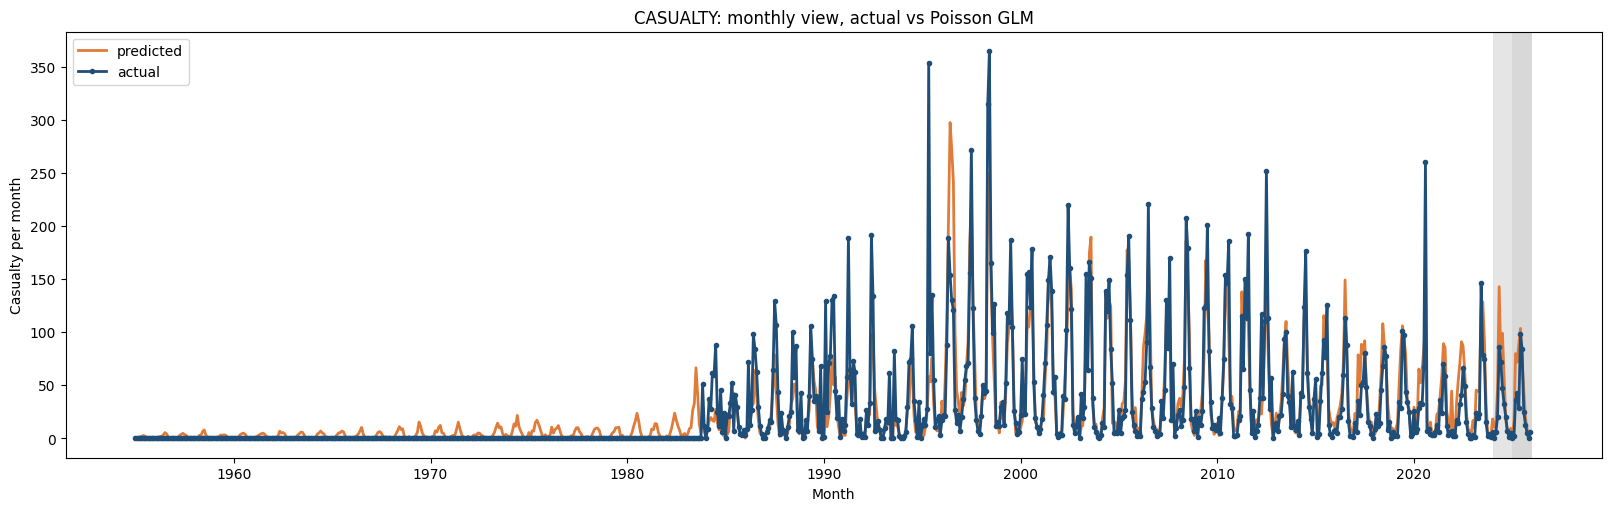

In [ ]:
plot_monthly_actual_vs_predicted(forecast_results, target="CASUALTY", model='GLM')

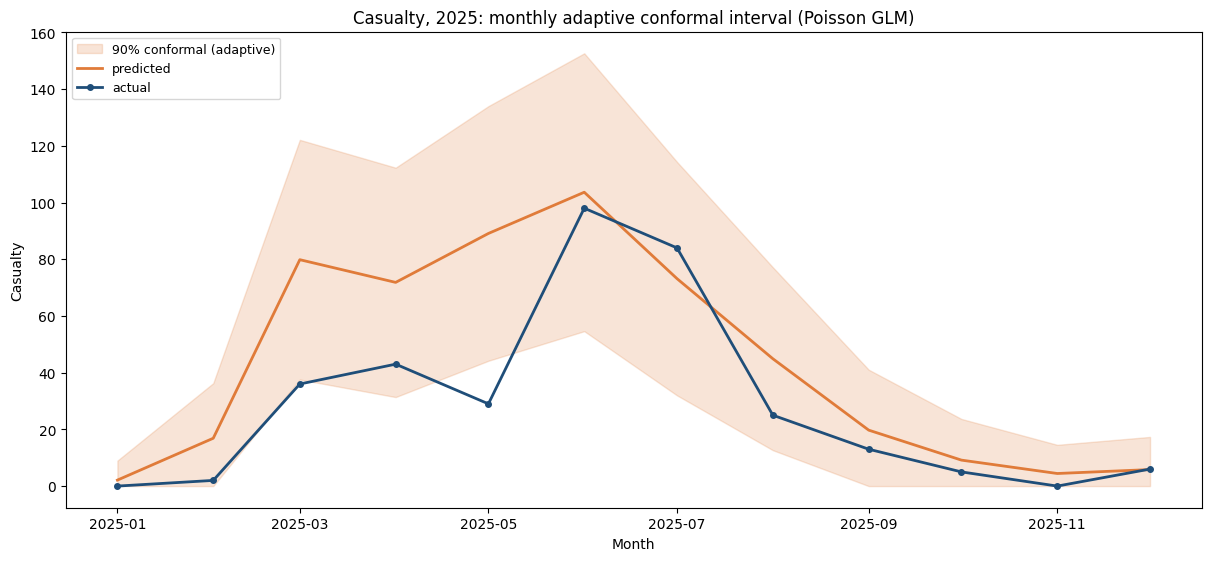

In [ ]:
plot_conformal_monthly(forecast_results, target="CASUALTY", model='GLM', test_year=2025)

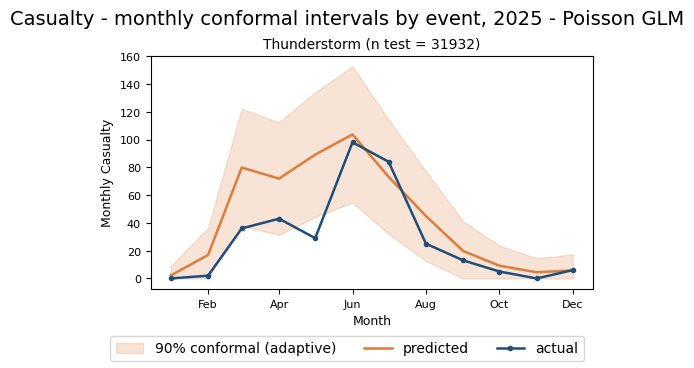

In [ ]:
plot_conformal_monthly_by_event(forecast_results, target='CASUALTY', model='GLM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: CASUALTY (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


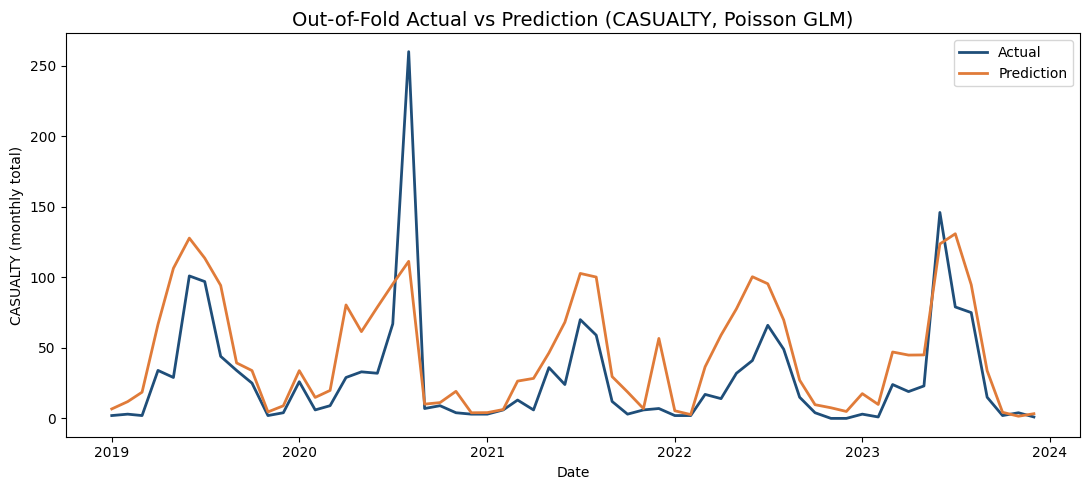

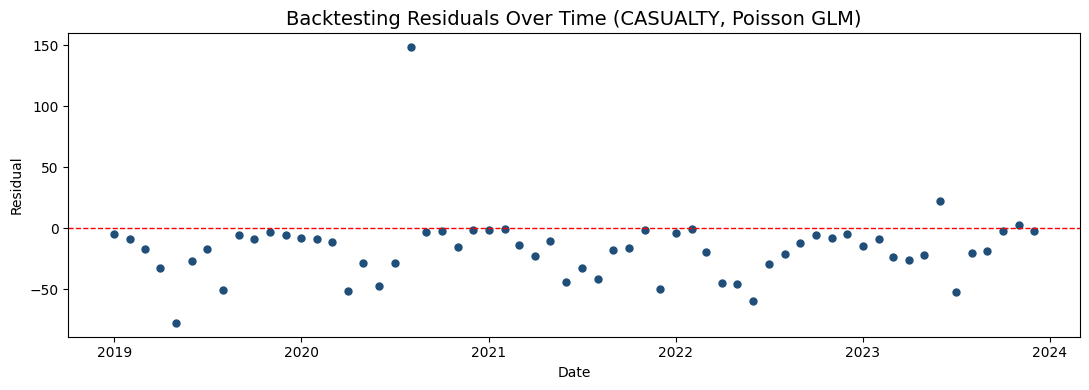

,n,events,D2,RMSE,MPD
2019,29394.0,191.0,0.2645,0.2832,0.1035
2020,28689.0,163.0,0.3061,1.2003,0.1590
2021,23409.0,138.0,0.2178,0.1800,0.0882
2022,26083.0,148.0,0.2450,0.1777,0.0765
2023,34137.0,178.0,0.1595,0.5207,0.1186
Mean,28342.4,163.6,0.2386,0.4724,0.1092


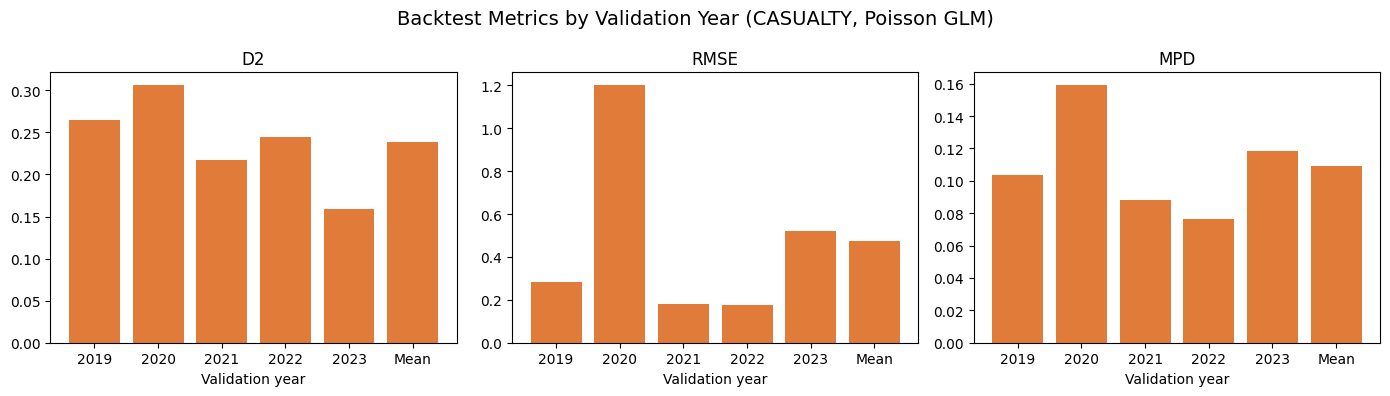

In [ ]:
backtest_target_cv(
    train_events,
    'CASUALTY',
    params=BEST_ALPHA['CASUALTY'],
    model='GLM',
)

## LightGBM

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LGBM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      PREDICTION_TARGETS,
#      model='LGBM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=15,
#)
#print("New BEST_PARAMETERS dictionary:", BEST_PARAMETERS_LGBM_TUNED)

Tuning LightGBM Poisson for target CASUALTY...
Precomputing 5 folds for CASUALTY...
  best parameters: {'n_estimators': 500, 'learning_rate': 0.011331720162347226, 'num_leaves': 67, 'min_child_samples': 224, 'min_child_weight': 0.01, 'subsample': 0.6461304152924394, 'subsample_freq': 1, 'colsample_bytree': 0.7361780563795438, 'reg_lambda': 1.0589421694411916, 'poisson_max_delta_step': 0.08326166418096587}
New BEST_PARAMETERS dictionary: {'CASUALTY': {'n_estimators': 500, 'learning_rate': 0.011331720162347226, 'num_leaves': 67, 'min_child_samples': 224, 'min_child_weight': 0.01, 'subsample': 0.6461304152924394, 'subsample_freq': 1, 'colsample_bytree': 0.7361780563795438, 'reg_lambda': 1.0589421694411916, 'poisson_max_delta_step': 0.08326166418096587}}


### Prediction

In [ ]:
LGBM_CASUALTY = {
    'n_estimators': 500,
    'learning_rate': 0.011331720162347226,
    'num_leaves': 67,
    'min_child_samples': 224,
    'min_child_weight': 0.01,
    'subsample': 0.6461304152924394,
    'subsample_freq': 1,
    'colsample_bytree': 0.7361780563795438,
    'reg_lambda': 1.0589421694411916,
    'poisson_max_delta_step': 0.08326166418096587
}



BEST_PARAMETERS = {
    'CASUALTY': dict(LGBM_CASUALTY)
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    PREDICTION_TARGETS,
    best_params=BEST_PARAMETERS,
    model='LGBM',
    group_column=GROUP_COL,
)
lgbm_results = forecast_results

[LightGBM Poisson] fitting CASUALTY...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='LGBM').round(4))

n  events      D2    RMSE     MPD
Target   Split                                              
CASUALTY train        970919    9682  0.7526  0.2277  0.0591
         calibration   29990     165  0.4555  0.1737  0.0600
         test          31932     173  0.4465  0.2593  0.0674

In [ ]:
display(point_metrics_by_event_group(forecast_results, targets='CASUALTY', model='LGBM').round(4))

n  events      D2    RMSE     MPD
Target   Split       EVENT_GROUP                                         
CASUALTY train       Thunderstorm  970919    9682  0.7526  0.2277  0.0591
         calibration Thunderstorm   29990     165  0.4555  0.1737  0.0600
         test        Thunderstorm   31932     173  0.4465  0.2593  0.0674

In [ ]:
display(daily_conformal_summary(forecast_results, model='LGBM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
CASUALTY,362,0.9199,0.942,2.3807,2.5273


In [ ]:
display(event_monthly_conformal_summary(forecast_results, model='LGBM').round(4))

,,Months,TestRecords,Coverage,MeanActual,MeanWidth,RelWidth
Target,EVENT_GROUP,,,,,,
CASUALTY,Thunderstorm,12,31932,0.9167,28.4167,30.1693,1.0617


### Visualization Results

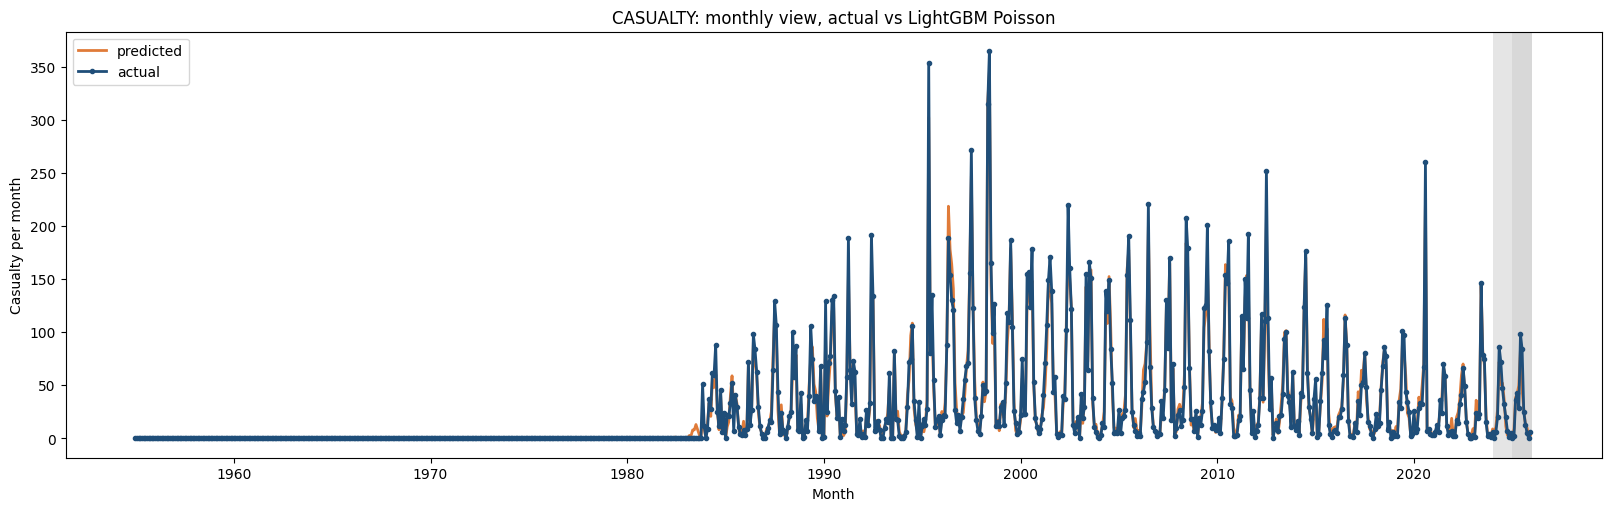

In [ ]:
plot_monthly_actual_vs_predicted(forecast_results, target="CASUALTY", model='LGBM')

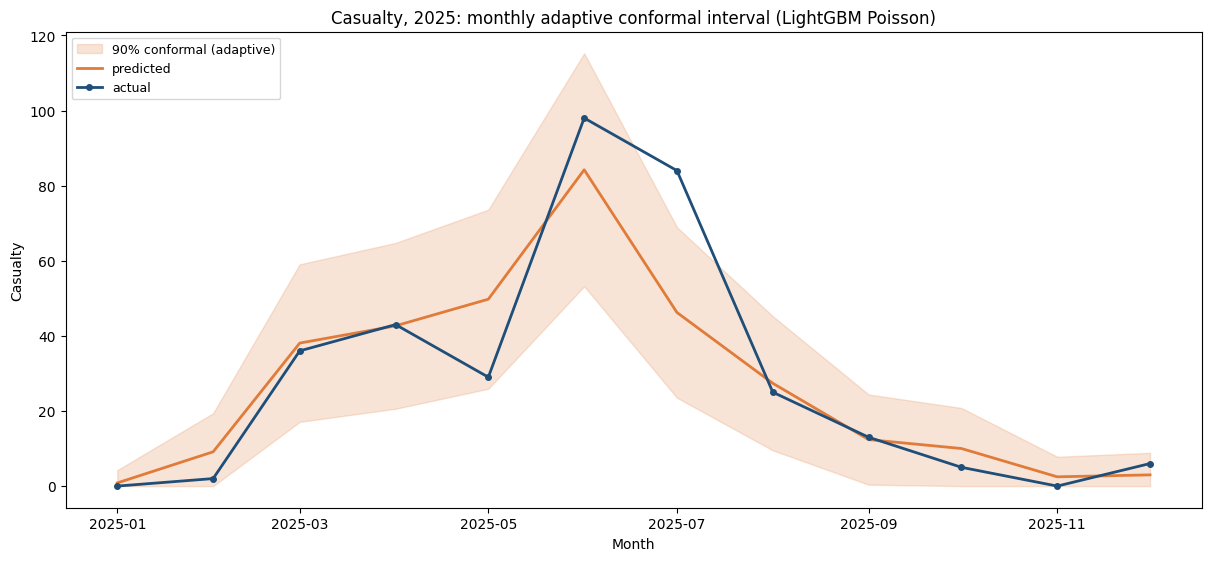

In [ ]:
plot_conformal_monthly(forecast_results, target="CASUALTY", model='LGBM', test_year=2025)

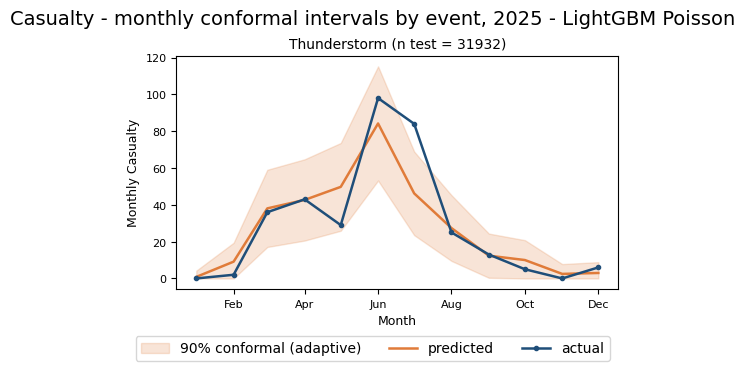

In [ ]:
plot_conformal_monthly_by_event(forecast_results, target='CASUALTY', model='LGBM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: CASUALTY (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


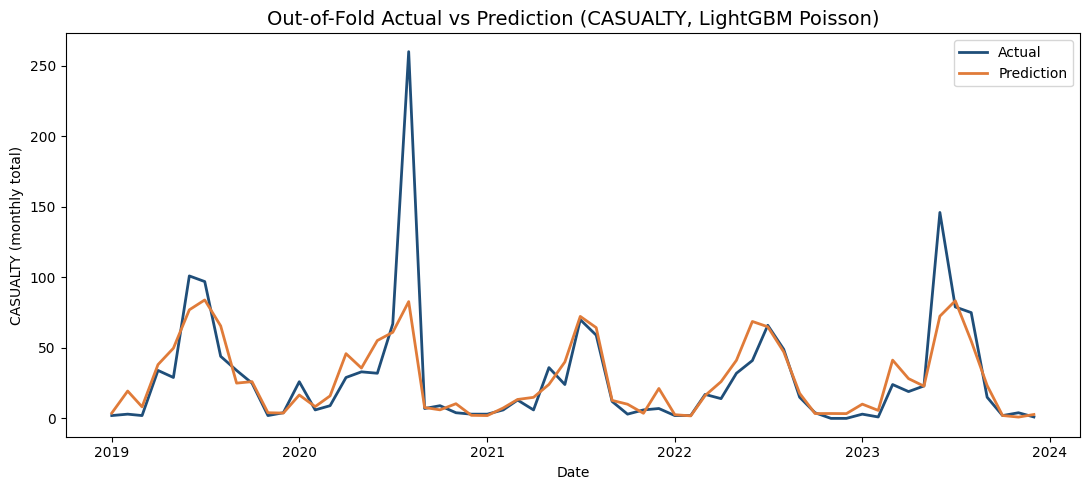

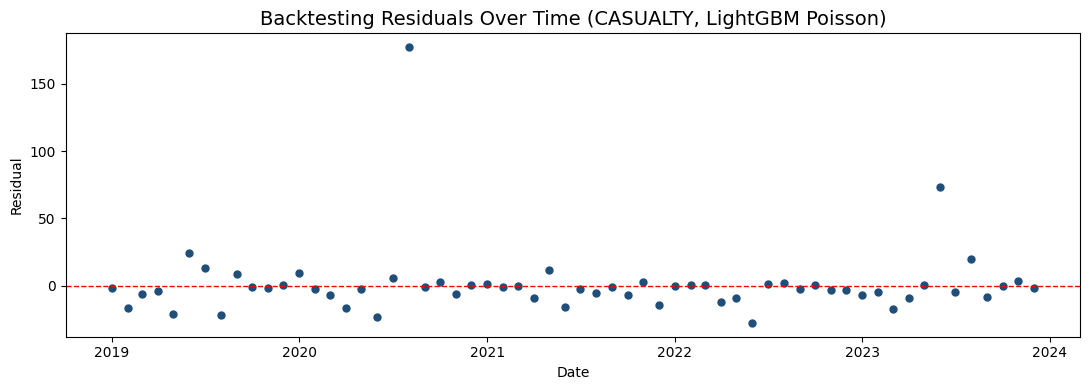

,n,events,D2,RMSE,MPD
2019,29394.0,191.0,0.3932,0.2870,0.0854
2020,28689.0,163.0,0.5477,1.1827,0.1037
2021,23409.0,138.0,0.4695,0.1698,0.0598
2022,26083.0,148.0,0.4177,0.1692,0.0590
2023,34137.0,178.0,0.3165,0.5233,0.0965
Mean,28342.4,163.6,0.4289,0.4664,0.0809


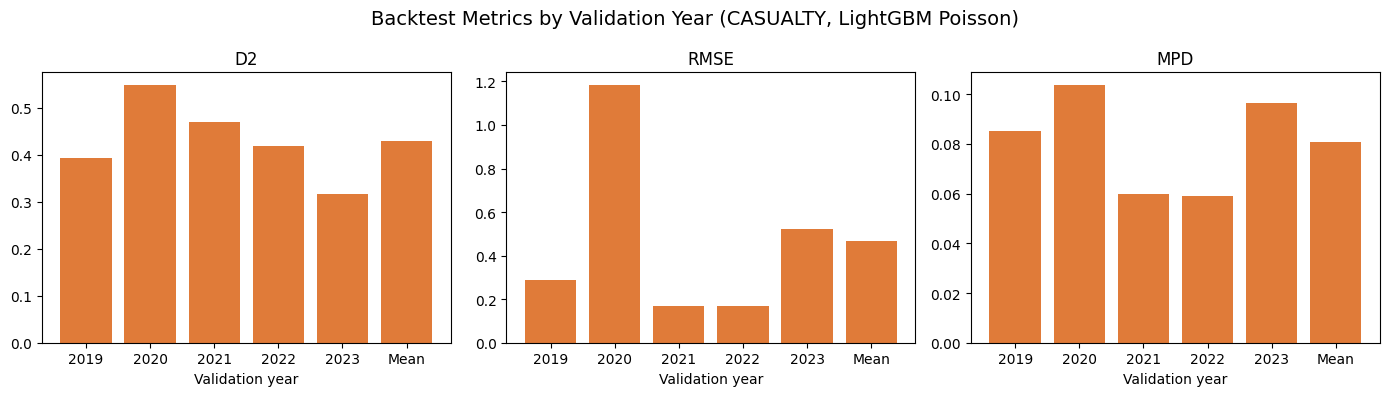

In [ ]:
backtest_target_cv(
    train_events,
    'CASUALTY',
    params=BEST_PARAMETERS['CASUALTY'],
    model='LGBM',
)

## LSTM

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS_LSTM with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LSTM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      PREDICTION_TARGETS,
#      model='LSTM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=15,
#)
#print("New BEST_PARAMETERS_LSTM dictionary:", BEST_PARAMETERS_LSTM_TUNED)

Tuning LSTM Poisson for target CASUALTY...
Precomputing 5 folds for CASUALTY...
  best parameters: {'sequence_length': 6, 'sequence_by': 'EVENT_GROUP', 'units': 16, 'dropout': 0.03552586614205752, 'learning_rate': 0.0013433361539196005, 'epochs': 7, 'batch_size': 256, 'verbose': 0}
New BEST_PARAMETERS_LSTM dictionary: {'CASUALTY': {'sequence_length': 6, 'sequence_by': 'EVENT_GROUP', 'units': 16, 'dropout': 0.03552586614205752, 'learning_rate': 0.0013433361539196005, 'epochs': 7, 'batch_size': 256, 'verbose': 0}}


### Prediction

In [ ]:
LSTM_CASUALTY = {
    'sequence_length': 6,
    'sequence_by': 'EVENT_GROUP',
    'units': 16,
    'dropout': 0.03552586614205752,
    'learning_rate': 0.0013433361539196005,
    'epochs': 7,
    'batch_size': 256,
    'verbose': 0
    }


BEST_PARAMETERS_LSTM = {
    'CASUALTY': dict(LSTM_CASUALTY)
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    PREDICTION_TARGETS,
    best_params=BEST_PARAMETERS_LSTM,
    model='LSTM',
    group_column=GROUP_COL,
)
lstm_results = forecast_results

[LSTM Poisson] fitting CASUALTY...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='LSTM').round(4))

n  events      D2    RMSE     MPD
Target   Split                                              
CASUALTY train        970919    9682  0.6564  0.3847  0.0821
         calibration   29990     165  0.4082  0.1815  0.0653
         test          31932     173  0.4263  0.2607  0.0698

In [ ]:
display(point_metrics_by_event_group(forecast_results, targets='CASUALTY', model='LSTM').round(4))

n  events      D2    RMSE     MPD
Target   Split       EVENT_GROUP                                         
CASUALTY train       Thunderstorm  970919    9682  0.6564  0.3847  0.0821
         calibration Thunderstorm   29990     165  0.4082  0.1815  0.0653
         test        Thunderstorm   31932     173  0.4263  0.2607  0.0698

In [ ]:
display(daily_conformal_summary(forecast_results, model='LSTM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
CASUALTY,362,0.9144,0.942,2.3165,2.4591


In [ ]:
display(event_monthly_conformal_summary(forecast_results, model='LSTM').round(4))

,,Months,TestRecords,Coverage,MeanActual,MeanWidth,RelWidth
Target,EVENT_GROUP,,,,,,
CASUALTY,Thunderstorm,12,31932,0.8333,28.4167,29.6079,1.0419


### Visualization Results

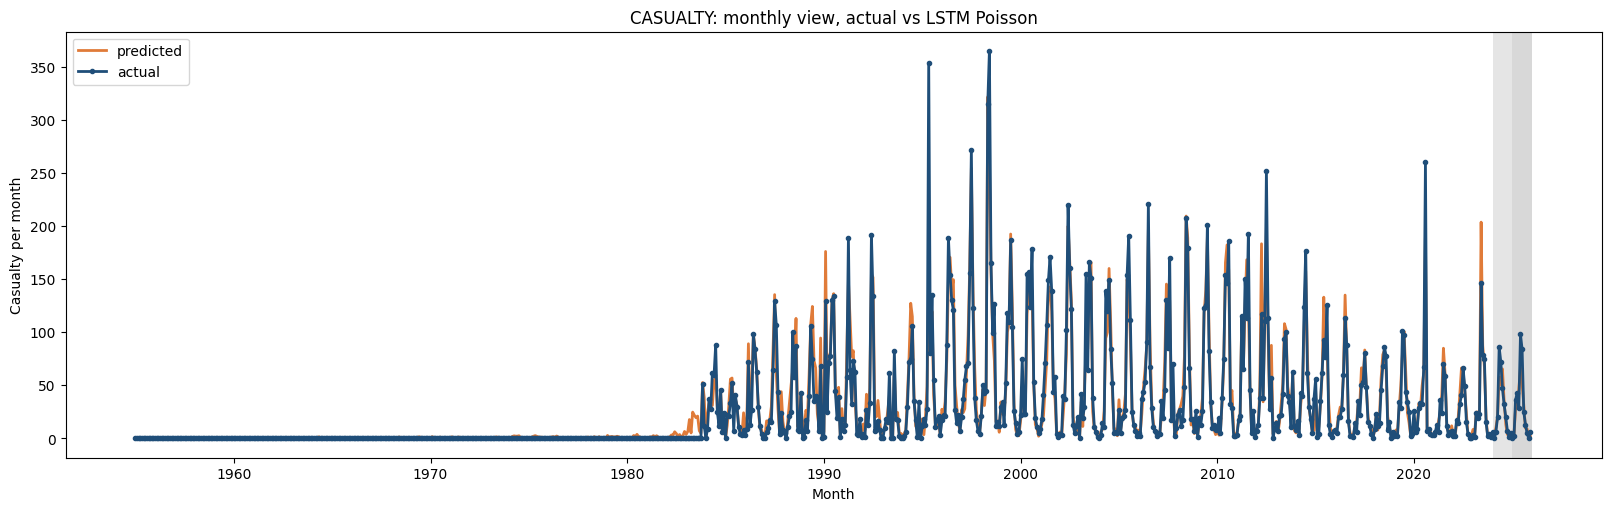

In [ ]:
plot_monthly_actual_vs_predicted(forecast_results, target="CASUALTY", model='LSTM')

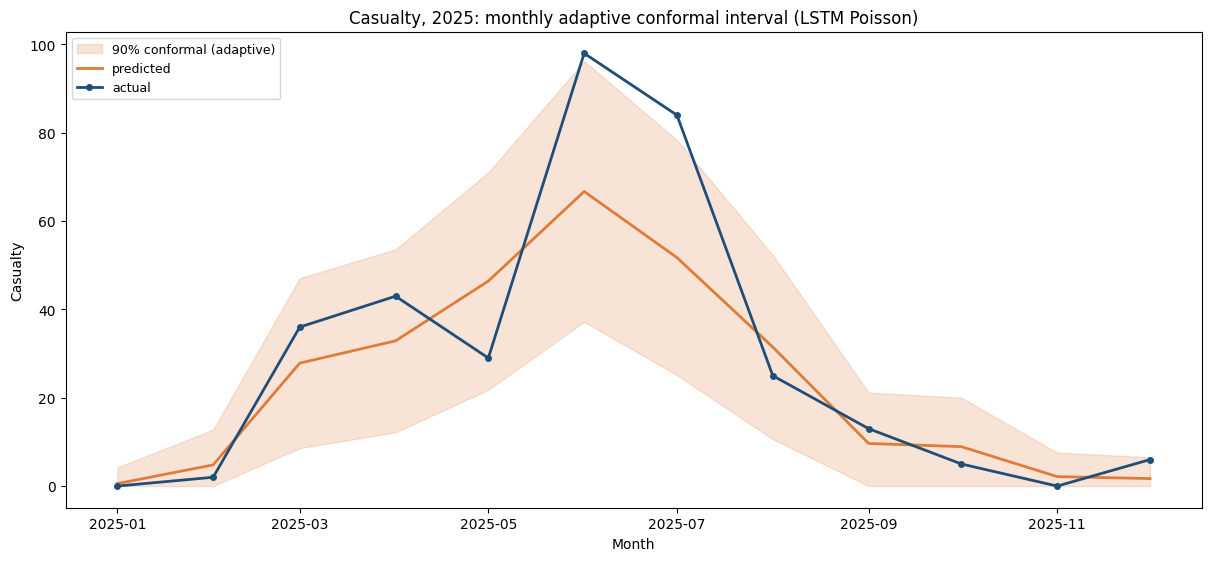

In [ ]:
plot_conformal_monthly(forecast_results, target="CASUALTY", model='LSTM', test_year=2025)

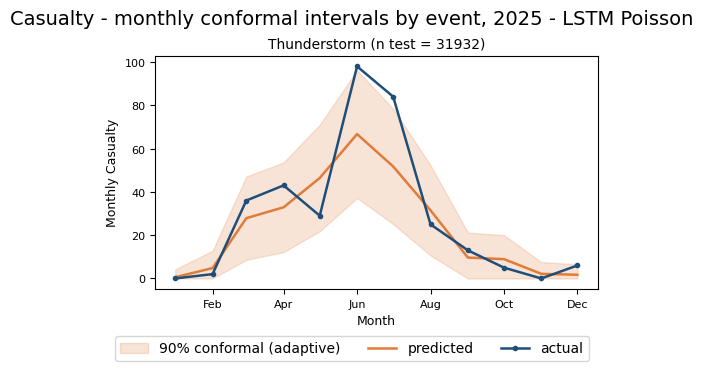

In [ ]:
plot_conformal_monthly_by_event(forecast_results, target='CASUALTY', model='LSTM', test_year=2025)

### Backtesting Results



 BACKTESTING FOR TARGET: CASUALTY (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


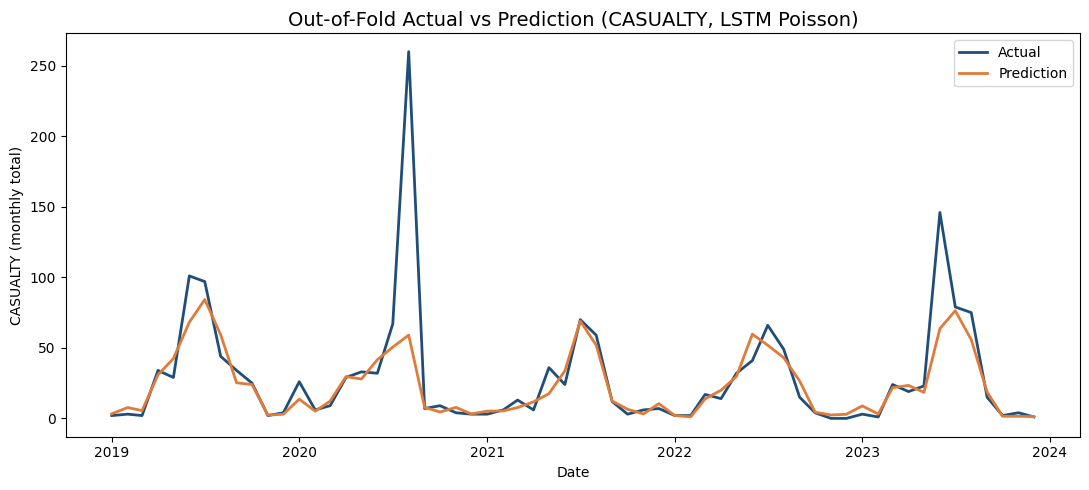

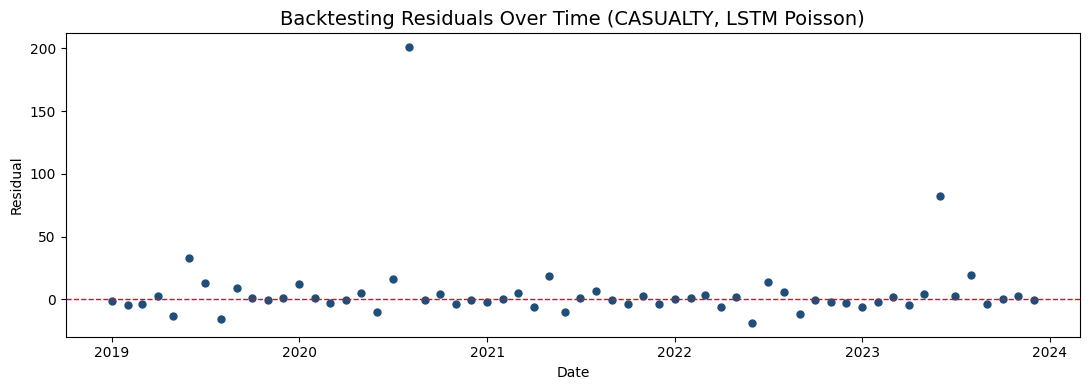

,n,events,D2,RMSE,MPD
2019,29394.0,191.0,0.4129,0.2792,0.0826
2020,28689.0,163.0,0.5018,1.1946,0.1142
2021,23409.0,138.0,0.4524,0.1659,0.0617
2022,26083.0,148.0,0.4309,0.1757,0.0577
2023,34137.0,178.0,0.3548,0.5186,0.0910
Mean,28342.4,163.6,0.4305,0.4668,0.0814


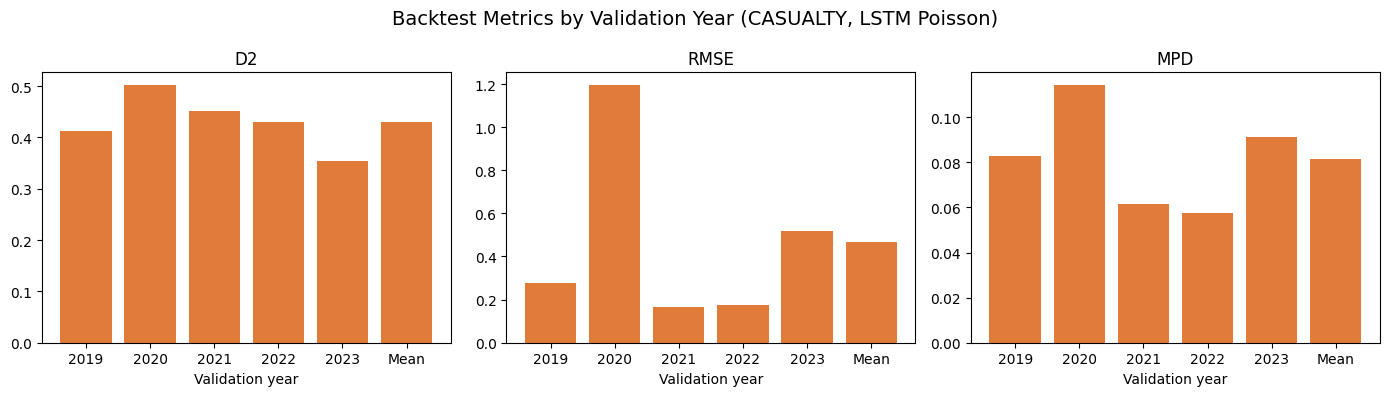

In [ ]:
backtest_target_cv(
    train_events,
    'CASUALTY',
    params=BEST_PARAMETERS_LSTM['CASUALTY'],
    model='LSTM',
)

## TabPFN

### Model setup

In [ ]:
##############################################################################
# TABPFN: A TABULAR FOUNDATION MODEL
##############################################################################

TABPFN_PARAMS = {
    # --- counting structure
    "target_transform": "log1p",
    "bias_correction": True,
    "level_split": "train",
    "level_min_events": 10,

    # --- target-aware context
    # Keep every available positive case first, then sample zeros until the
    # context reaches 50,000 rows. This is repeated independently for each
    # target and inside every historical backtest fold.
    "context_size": 50000,
    "context_seed": RANDOM_STATE,

    # --- runtime
    "n_estimators": 22,
    "subsample_samples": 50000,
    "predict_batch_size": 4096,
    "device": "auto",
    "fit_mode": "fit_with_cache",
    "verbose": True,
}

MODEL_SPECS["TABPFN"] = {
    "label": "TabPFN-3",
    "nominal_encoding": "category",
    "scale_numeric": False,
    "scalar_param": None,
    "fit_kind": "foundation",
    "default_params": dict(TABPFN_PARAMS),
}


def make_tabpfn_regressor(params, categorical_indices):
    """TabPFN-3 regressor, one ensemble over a subsampled context."""
    return TabPFNRegressor.create_default_for_version(
        ModelVersion.V3,
        device=params["device"],
        n_estimators=params["n_estimators"],
        fit_mode=params["fit_mode"],
        categorical_features_indices=categorical_indices,
        ignore_pretraining_limits=True,
        inference_config={"SUBSAMPLE_SAMPLES": params["subsample_samples"]},
        random_state=RANDOM_STATE,
    )


def tabpfn_matrix(X):
    """Numeric matrix plus the positions of the categorical columns."""
    values = X.copy()
    indices = [X.columns.get_loc(column) for column in categorical_columns(X)]

    for position in indices:
        codes = values.iloc[:, position].cat.codes.astype("float64")
        values.iloc[:, position] = codes.mask(codes < 0.0)

    return values.to_numpy(dtype="float64"), indices


### TabPFN In-Context Learning for Count Prediction

In [ ]:
def fit_predict_foundation(matrices, params, fit_on, model):
    """Target-stratified TabPFN V3 context in, Poisson-shaped counts out.

    1. Context: every positive row of the fit split, plus zero rows sampled at
       random until the context reaches context_size rows, in shuffled order.
    2. Fit: TabPFN on log1p of the rate over that context.
    3. Predict: every split in batches, back on the counting scale.
    4. Level correction: each event group is rescaled by actual over predicted
       on the level split, when it has at least level_min_events events;
       groups with less signal take the global factor."""
    # --- 1. target-stratified context
    y_fit_full = matrices["y"][fit_on]
    rng = np.random.default_rng(params["context_seed"])
    positive_positions = np.flatnonzero(y_fit_full > 0)
    zero_positions = np.flatnonzero(y_fit_full <= 0)

    selected_zero = rng.choice(
        zero_positions, size=params["context_size"] - len(positive_positions), replace=False
    )
    context_positions = np.concatenate([positive_positions, selected_zero])
    rng.shuffle(context_positions)

    # --- 2. fit on the log1p rate
    X_fit = matrices["X"][fit_on].iloc[context_positions]
    y_fit = y_fit_full[context_positions]
    exposure_fit = matrices["exposure"][fit_on][context_positions]

    context_values, categorical_indices = tabpfn_matrix(X_fit)
    estimator = make_tabpfn_regressor(params, categorical_indices)
    estimator.fit(context_values, np.log1p(y_fit / exposure_fit))

    # --- 3. predict every split in batches, back on the counting scale
    batch_size = params["predict_batch_size"]
    predicted = {}
    for name, X in matrices["X"].items():
        values, _ = tabpfn_matrix(X)
        log_rate = np.concatenate([
            estimator.predict(values[start:start + batch_size], output_type="mean")
            for start in range(0, len(values), batch_size)
        ])
        predicted[name] = np.clip(np.expm1(log_rate), 0.0, None) * matrices["exposure"][name]

    del estimator
    gc.collect()
    torch.cuda.empty_cache()

    # --- 4. group level correction
    level_split = params["level_split"]
    frame = pd.DataFrame({
        "y": matrices["y"][level_split],
        "p": predicted[level_split],
        "g": matrices["prepared"][level_split][GROUP_COL].to_numpy(),
    })
    totals = frame.groupby("g")[["y", "p"]].sum()

    global_factor = frame["y"].sum() / frame["p"].sum()
    has_signal = (totals["y"] >= params["level_min_events"]) & (totals["p"] > 0.0)
    factors = (totals["y"] / totals["p"]).where(has_signal, global_factor).to_dict()

    print(
        f"    level correction on {level_split}: global x{global_factor:.4f}, "
        f"{int(has_signal.sum())}/{len(factors)} groups on their own factor"
    )

    predicted = {
        name: np.clip(
            values
            * matrices["prepared"][name][GROUP_COL].map(factors).fillna(global_factor).to_numpy(dtype="float64"),
            1e-6,
            None,
        )
        for name, values in predicted.items()
    }

    return None, predicted

### One target end to end

In [ ]:
###############################################################
# TabPFN now rides the shared pipeline
###############################################################


def build_forecast_results_tabpfn(
    train_df,
    calibration_df,
    test_df,
    targets,
    params=None,
    alpha_target=0.10,
    gamma=0.01,
    #group_column=GROUP_COL,
):
    """One TabPFN result per outcome, same design as build_forecast_results."""
    return build_forecast_results(
        train_df=train_df,
        calibration_df=calibration_df,
        test_df=test_df,
        targets=targets,
        best_params={target: params for target in targets},
        model="TABPFN",
        alpha_target=alpha_target,
        gamma=gamma,
        #group_column=group_column,
    )


def build_forecast_results_tabpfn(
    train_df,
    calibration_df,
    test_df,
    targets,
    params=None,
    alpha_target=0.10,
    gamma=0.01,
    #group_column=GROUP_COL,
):
    """One TabPFN result per outcome, same design as build_forecast_results."""
    return build_forecast_results(
        train_df=train_df,
        calibration_df=calibration_df,
        test_df=test_df,
        targets=targets,
        best_params={target: params for target in targets},
        model="TABPFN",
        alpha_target=alpha_target,
        gamma=gamma,
        #group_column=group_column,
    )


### Prediction

In [ ]:
tabpfn_results = build_forecast_results_tabpfn(
    train_events,
    calibration_events,
    test_events,
    PREDICTION_TARGETS,
    params=TABPFN_PARAMS,
    #group_column=GROUP_COL,
)
forecast_results = tabpfn_results


[TabPFN-3] fitting CASUALTY...


tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

    level correction on train: global x0.3402, 1/1 groups on their own factor


### Reporting Results

In [ ]:
display(point_metrics_by_target(tabpfn_results, model='TABPFN').round(4))

n  events      D2    RMSE     MPD
Target   Split                                              
CASUALTY train        970919    9682  0.6755  0.4861  0.0775
         calibration   29990     165  0.4760  0.1764  0.0578
         test          31932     173  0.4613  0.2569  0.0656

In [ ]:
display(point_metrics_by_event_group(tabpfn_results, targets='CASUALTY', model='TABPFN').round(4))

n  events      D2    RMSE     MPD
Target   Split       EVENT_GROUP                                         
CASUALTY train       Thunderstorm  970919    9682  0.6755  0.4861  0.0775
         calibration Thunderstorm   29990     165  0.4760  0.1764  0.0578
         test        Thunderstorm   31932     173  0.4613  0.2569  0.0656

In [ ]:
display(daily_conformal_summary(tabpfn_results, model='TABPFN').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
CASUALTY,362,0.9171,0.942,2.8862,3.064


In [ ]:
display(event_monthly_conformal_summary(tabpfn_results, model='TABPFN').round(4))

,,Months,TestRecords,Coverage,MeanActual,MeanWidth,RelWidth
Target,EVENT_GROUP,,,,,,
CASUALTY,Thunderstorm,12,31932,0.9167,28.4167,37.9655,1.336


### Visualization Results

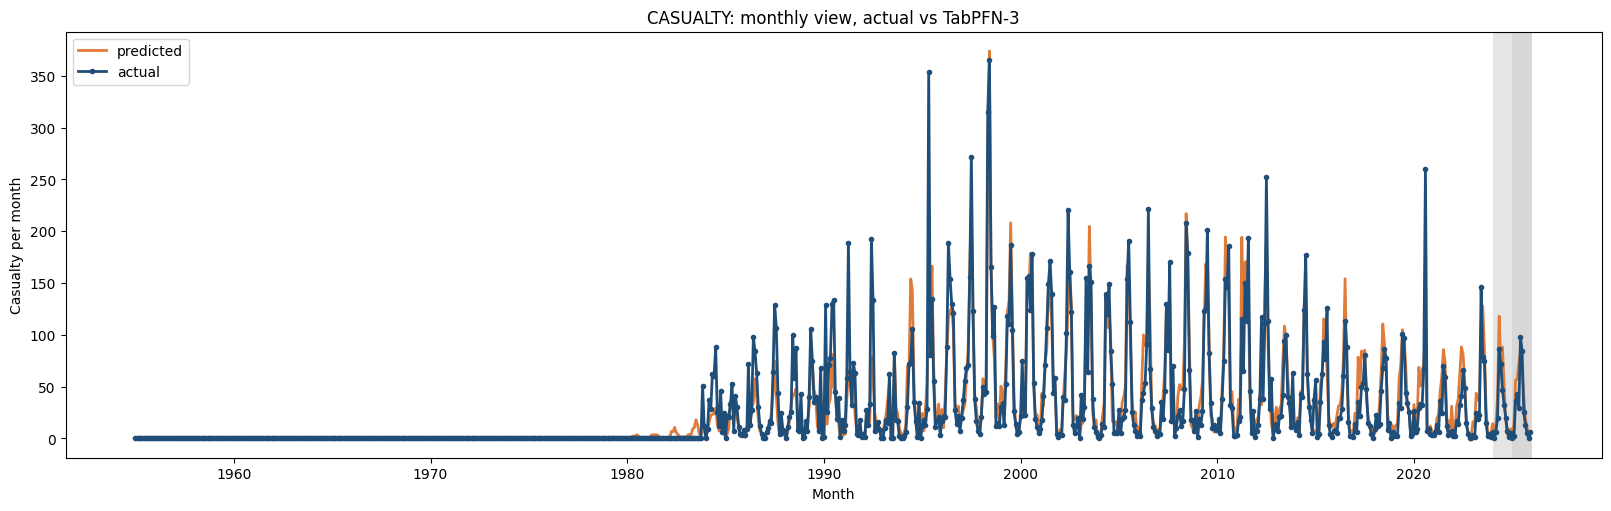

In [ ]:
plot_monthly_actual_vs_predicted(tabpfn_results, target="CASUALTY", model='TABPFN')

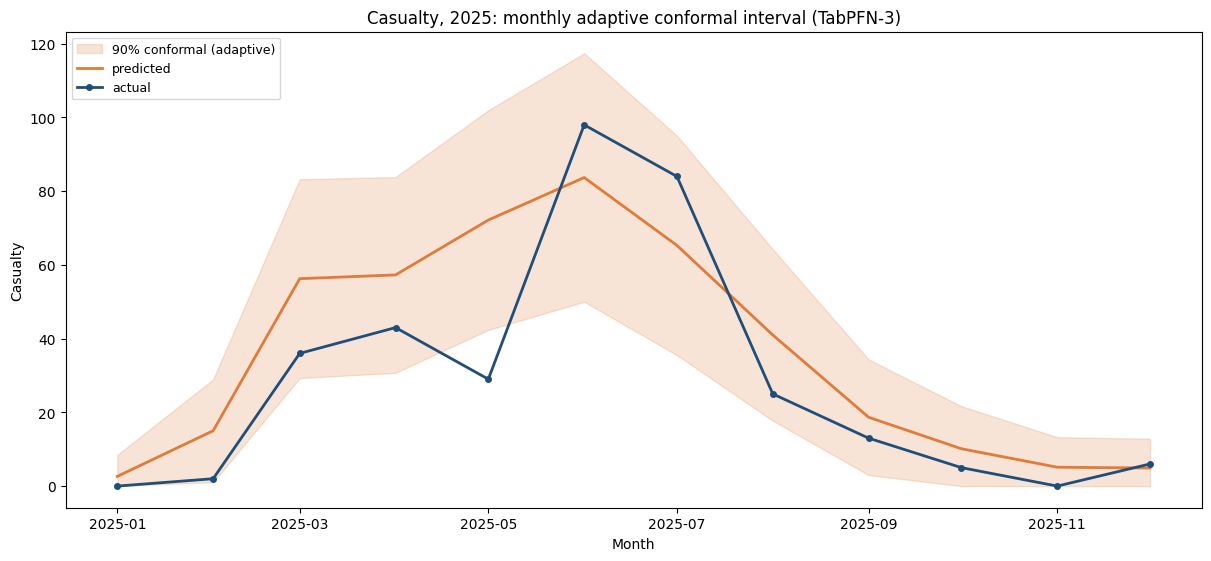

In [ ]:
plot_conformal_monthly(tabpfn_results, target="CASUALTY", model='TABPFN', test_year=2025)

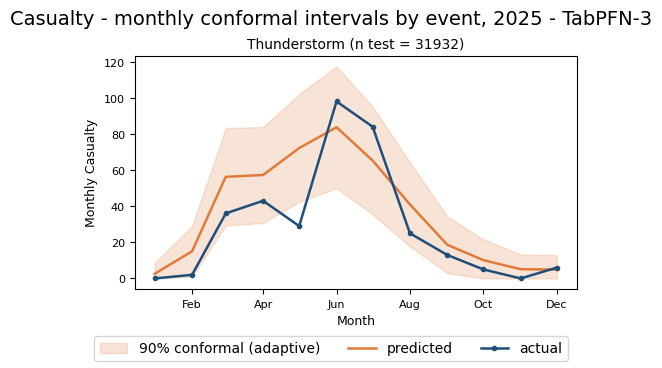

In [ ]:
plot_conformal_monthly_by_event(tabpfn_results, target='CASUALTY', model='TABPFN', test_year=2025)

### Backtesting Results

In [ ]:

###################################################
# Historical backtesting, TabPFN
###################################################

VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def backtest_target_cv_tabpfn(
    train_df,
    target,
    params=None,
    validation_years=VALIDATION_YEARS,
):
    """One target backtested on the shared expanding-window folds."""
    return backtest_target_cv(
        train_df=train_df,
        target=target,
        params=params,
        model="TABPFN",
        validation_years=validation_years,
    )



 BACKTESTING FOR TARGET: CASUALTY (TabPFN-3)
Fold 1: train <= 2018, validation = 2019
    level correction on train: global x0.3760, 1/1 groups on their own factor
Fold 2: train <= 2019, validation = 2020
    level correction on train: global x0.4097, 1/1 groups on their own factor
Fold 3: train <= 2020, validation = 2021
    level correction on train: global x0.3542, 1/1 groups on their own factor
Fold 4: train <= 2021, validation = 2022
    level correction on train: global x0.3468, 1/1 groups on their own factor
Fold 5: train <= 2022, validation = 2023
    level correction on train: global x0.3520, 1/1 groups on their own factor


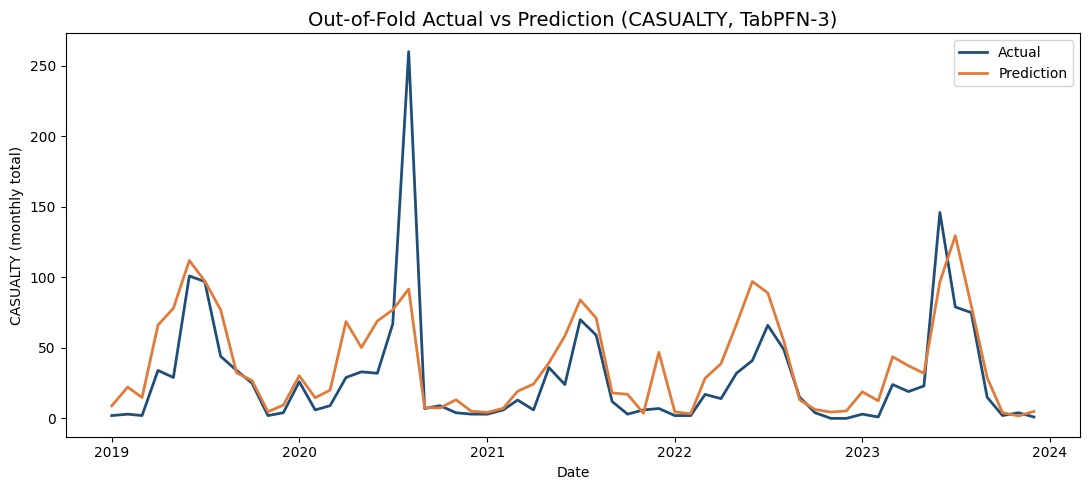

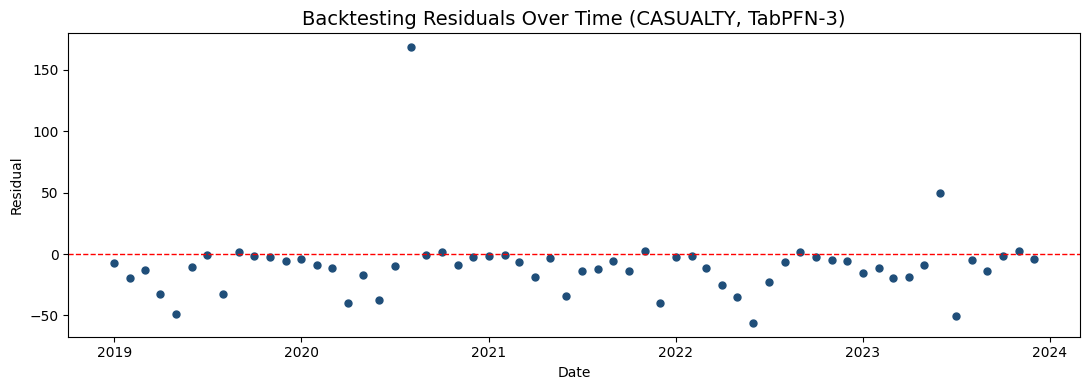

,n,events,D2,RMSE,MPD
2019,29394.0,191.0,0.4519,0.2802,0.0771
2020,28689.0,163.0,0.4594,1.1968,0.1239
2021,23409.0,138.0,0.4610,0.1687,0.0607
2022,26083.0,148.0,0.4066,0.1718,0.0601
2023,34137.0,178.0,0.4266,0.5174,0.0809
Mean,28342.4,163.6,0.4411,0.4670,0.0806


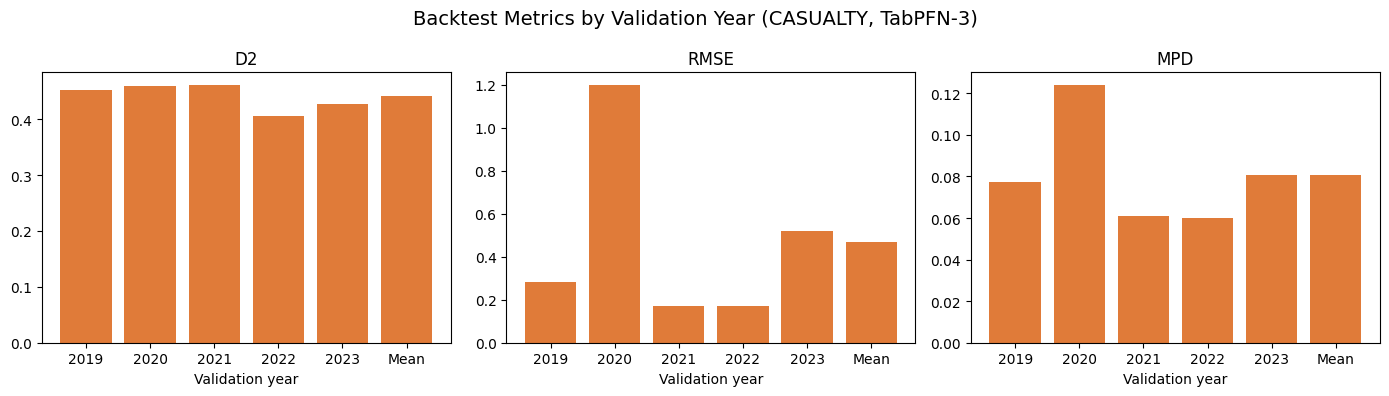

In [ ]:
backtest_target_cv_tabpfn(
    train_events,
    'CASUALTY',
    params=TABPFN_PARAMS,
    validation_years=VALIDATION_YEARS,
)

## From casualties to injuries and deaths

Each of the four models predicts one number per tornado: `CASUALTY`, injuries plus
deaths. This section checks whether that single prediction can be split into its two
parts **without building a second model**, and scores the split, model by model,
against the actual injuries and deaths.

In [ ]:
# ==============================================================================
# THE FOUR FITTED MODELS, IN COMPARISON ORDER
# ==============================================================================

MODEL_RESULTS = {
    "GLM": glm_results,
    "LGBM": lgbm_results,
    "LSTM": lstm_results,
    "TABPFN": tabpfn_results,
}

# Guards against a stale binding: each entry must carry its own model name.
for model_name, results in MODEL_RESULTS.items():
    _check_model(results, model_name)

print(
    "Models carried into the casualty split:",
    ", ".join(f"{name} ({model_label(name)})" for name in MODEL_RESULTS)
)

Models carried into the casualty split: GLM (Poisson GLM), LGBM (LightGBM Poisson), LSTM (LSTM Poisson), TABPFN (TabPFN-3)


In [ ]:
# ==============================================================================
# CASUALTY COMPONENTS, ALIGNED WITH MODEL SPLITS
# ==============================================================================

INJURY_PARTS = ["INJURIES_DIRECT", "INJURIES_INDIRECT"]
DEATH_PARTS = ["DEATHS_DIRECT", "DEATHS_INDIRECT"]
CASUALTY_PARTS = INJURY_PARTS + DEATH_PARTS

# The three modelling splits, in the order they occur in time.
SPLIT_FRAMES = {
    "train": train_events,
    "calibration": calibration_events,
    "test": test_events,
}


def build_casualty_splits(raw, model_splits):
    """Build injury/death components and align them with the model splits."""

    columns = ["BEGIN_DATE_TIME", "EVENT_GROUP", *CASUALTY_PARTS]
    components = raw[columns].copy()

    # Same row preparation used for the modelling dataset
    components["BEGIN_DATE_TIME"] = parse_storm_datetime(
        components["BEGIN_DATE_TIME"]
    )

    components = components.dropna(subset=["BEGIN_DATE_TIME"])
    components = components.loc[
        ~components["EVENT_GROUP"].isin(EXCLUDE_GROUPS)
    ]

    components.index = pd.DatetimeIndex(
        components["BEGIN_DATE_TIME"],
        name="Date"
    )

    components = components.sort_index(kind="stable")

    # Numerical casualty components
    components[CASUALTY_PARTS] = components[CASUALTY_PARTS].astype("float64")

    components["INJURIES"] = components[INJURY_PARTS].sum(axis=1)
    components["DEATHS"] = components[DEATH_PARTS].sum(axis=1)

    components = components.drop(
        columns=["BEGIN_DATE_TIME", "EVENT_GROUP"]
    )

    # Align with the exact modelling splits
    components_by_split = {}

    for split_name, model_frame in model_splits.items():

        part = components.loc[
            model_frame.index.min():model_frame.index.max()
        ]

        # Same rows and same order
        assert part.index.equals(model_frame.index), (
            f"{split_name}: casualty rows are not aligned"
        )

        # Injuries + deaths must reproduce CASUALTY exactly
        rebuilt_casualty = (
            part["INJURIES"] + part["DEATHS"]
        ).to_numpy()

        assert np.allclose(
            rebuilt_casualty,
            model_frame["CASUALTY"].to_numpy()
        ), f"{split_name}: casualty target mismatch"

        components_by_split[split_name] = part

    return components_by_split


def check_prediction_alignment(
    components_by_split,
    model_results,
    target="CASUALTY"
):
    """Every model must predict on exactly the rows the components describe.

    The components are actual values read from the raw file; the predictions
    come out of each model's own matrices. Multiplying one by a share and
    scoring it against the other only means something if the two carry the
    same events in the same order.
    """

    for model_name, results in model_results.items():

        predictions = results[target]["predictions"]

        for split_name, part in components_by_split.items():

            predicted_rows = predictions.index[
                predictions["split"].eq(split_name)
            ]

            assert predicted_rows.equals(part.index), (
                f"{model_name}/{split_name}: predicted rows are not aligned "
                f"with the casualty components "
                f"({len(predicted_rows)} predicted, {len(part)} actual)"
            )


components_by_split = build_casualty_splits(
    raw=df,
    model_splits=SPLIT_FRAMES
)

check_prediction_alignment(
    components_by_split,
    MODEL_RESULTS
)

print(
    "Components rebuilt and aligned:",
    {name: len(part) for name, part in components_by_split.items()}
)

Components rebuilt and aligned: {'train': 970919, 'calibration': 29990, 'test': 31932}


In [ ]:
# ==============================================================================
# INJURIES VS DEATHS, SPLIT BY SPLIT
# ==============================================================================

LARGE_EVENT_CASUALTIES = 100


def injury_death_summary(part):

    injuries = part["INJURIES"]
    deaths = part["DEATHS"]
    casualties = injuries + deaths

    without_large_events = casualties <= LARGE_EVENT_CASUALTIES
    total_casualties = casualties.sum()

    return {
        "events": len(part),

        "Pearson":
            injuries.corr(deaths),

        "Spearman":
            injuries.corr(deaths, method="spearman"),

        "Pearson without large events":
            injuries[without_large_events].corr(
                deaths[without_large_events]
            ),

        "P(deaths>0 | injuries>0)":
            deaths[injuries > 0].gt(0).mean(),

        "P(deaths>0 | injuries=0)":
            deaths[injuries == 0].gt(0).mean(),

        "death share":
            deaths.sum() / total_casualties
            if total_casualties > 0 else np.nan,
    }

In [ ]:
###########################################
# DEATHS BY INJURY SIZE
###########################################
INJURY_SIZE_BINS = [0, 5, 20, 100, np.inf]
INJURY_SIZE_LABELS = ["1-5", "6-20", "21-100", ">100"]


def deaths_by_injury_size(part):

    injured = part.loc[
        part["INJURIES"] > 0,
        ["INJURIES", "DEATHS"]
    ]

    injury_size = pd.cut(
        injured["INJURIES"],
        bins=INJURY_SIZE_BINS,
        labels=INJURY_SIZE_LABELS
    )

    grouped = injured.groupby(
        injury_size,
        observed=False
    )["DEATHS"]

    summary = grouped.agg(
        events="size",
        death_probability=lambda deaths: deaths.gt(0).mean(),
        mean_deaths="mean"
    )

    return summary.rename(
        columns={
            "death_probability": "share with at least one death",
            "mean_deaths": "mean deaths",
        }
    )

In [ ]:
# ==============================================================================
# DIRECT VS INDIRECT CASUALTIES, SPLIT BY SPLIT
# ==============================================================================

def direct_indirect_summary(part):

    casualty_parts = part[CASUALTY_PARTS]

    # Calculate once
    events = casualty_parts.gt(0).sum()
    totals = casualty_parts.sum()

    summary = {}

    for column in CASUALTY_PARTS:

        label = column.lower().replace("_", " ")

        summary[f"events with {label}"] = int(events[column])
        summary[f"total {label}"] = float(totals[column])

    total_injuries = totals[INJURY_PARTS].sum()
    total_deaths = totals[DEATH_PARTS].sum()

    summary["indirect share of injuries"] = (
        totals["INJURIES_INDIRECT"] / total_injuries
        if total_injuries > 0 else np.nan
    )

    summary["indirect share of deaths"] = (
        totals["DEATHS_INDIRECT"] / total_deaths
        if total_deaths > 0 else np.nan
    )

    return summary

#### How injuries and deaths move together

* **Pearson correlation**: agreement of the *values*. It is driven by the few large events.
* **Spearman correlation**: agreement of the *rankings*. It gives small and large events the same weight.
* **P(deaths > 0 | injuries > 0)**: among tornadoes that injured someone, the share that also killed someone.
* **Death share**: deaths as a fraction of all casualties.

A high Pearson with a low Spearman means injuries and deaths rise together in big events, while on small events deaths are rare and unrelated to the number injured.

The second table shows the death share by event size.

In [ ]:
for split_name in SPLIT_ORDER:

    part = components_by_split[split_name]

    print(f"\n{'=' * 60}")
    print(split_name.upper())
    print("=" * 60)

    # Table 1: injuries vs deaths
    print("\nInjuries vs deaths")

    display(
        pd.DataFrame(
            injury_death_summary(part),
            index=[split_name]
        ).round(4)
    )

    # Table 2: deaths by injury size
    print("\nDeaths by injury size")

    display(
        deaths_by_injury_size(part).round(3)
    )


TRAIN

Injuries vs deaths


,events,Pearson,Spearman,Pearson without large events,P(deaths>0 | injuries>0),P(deaths>0 | injuries=0),death share
train,970919,0.1083,0.1625,0.1139,0.0826,0.0014,0.1085



Deaths by injury size


,events,share with at least one death,mean deaths
INJURIES,,,
1-5,7733,0.078,0.092
6-20,501,0.136,0.244
21-100,66,0.182,0.333
>100,2,0.500,0.500



CALIBRATION

Injuries vs deaths


...

,events,share with at least one death,mean deaths
INJURIES,,,
1-5,113,0.115,0.115
6-20,5,0.400,0.400
21-100,0,NaN,NaN
>100,0,NaN,NaN



TEST

Injuries vs deaths


,events,Pearson,Spearman,Pearson without large events,P(deaths>0 | injuries>0),P(deaths>0 | injuries=0),death share
test,31932,0.1671,0.1875,0.1671,0.1168,0.0011,0.1994



Deaths by injury size


,events,share with at least one death,mean deaths
INJURIES,,,
1-5,131,0.099,0.099
6-20,5,0.400,0.400
21-100,1,1.000,2.000
>100,0,NaN,NaN


#### Direct and indirect casualties

NOAA records each casualty as **direct**, caused by the tornado itself, or **indirect**, caused by something the tornado set off. The target adds the two together. The table shows how much each part weighs.

In [ ]:
# ==============================================================================
# DIRECT VS INDIRECT CASUALTIES, SPLIT BY SPLIT
# ==============================================================================

print("Direct vs indirect casualties, by split")

display(
    pd.DataFrame({
        split_name: direct_indirect_summary(part)
        for split_name, part in components_by_split.items()
    }).round(4)
)

Direct vs indirect casualties, by split


,train,calibration,test
events with injuries direct,7903.0000,108.0000,127.0000
total injuries direct,18712.0000,203.0000,232.0000
events with injuries indirect,430.0000,10.0000,13.0000
total injuries indirect,1145.0000,25.0000,41.0000
events with deaths direct,1849.0000,49.0000,45.0000
total deaths direct,2147.0000,53.0000,60.0000
events with deaths indirect,219.0000,14.0000,7.0000
total deaths indirect,269.0000,21.0000,8.0000
indirect share of injuries,0.0577,0.1096,0.1502
indirect share of deaths,0.1113,0.2838,0.1176


#### Splitting the casualty prediction

The split is a fixed proportion, not a second model: each predicted casualty count is
multiplied by the share that component holds over the **training years**, and the
product is scored against the actual component. The same shares are applied to the
four models, so the tables below read as the price of the split on top of each model's
casualty prediction.

In [ ]:
# ==============================================================================
# CASUALTY SHARES ESTIMATED ON THE TRAINING SET
# ==============================================================================

training_components = components_by_split["train"]

total_casualties = training_components[CASUALTY_PARTS].to_numpy().sum()

PART_SHARES = {
    column_name: training_components[column_name].sum() / total_casualties
    for column_name in CASUALTY_PARTS
}

# Injuries and deaths are the sums of their direct and indirect parts
SHARES = dict(PART_SHARES)

SHARES["INJURIES"] = (
    PART_SHARES["INJURIES_DIRECT"]
    + PART_SHARES["INJURIES_INDIRECT"]
)

SHARES["DEATHS"] = (
    PART_SHARES["DEATHS_DIRECT"]
    + PART_SHARES["DEATHS_INDIRECT"]
)

DEATH_SHARE = SHARES["DEATHS"]


print("Shares estimated on the training years:")

display(
    pd.Series(
        SHARES,
        name="share of casualties"
    ).round(4)
)

Shares estimated on the training years:


,share of casualties
INJURIES_DIRECT,0.8401
INJURIES_INDIRECT,0.0514
DEATHS_DIRECT,0.0964
DEATHS_INDIRECT,0.0121
INJURIES,0.8915
DEATHS,0.1085


In [ ]:
# ==============================================================================
# CONSTANT-SHARE SPLIT OF THE CASUALTY PREDICTION, MODEL BY MODEL
# ==============================================================================

def component_metrics_for_model(results, shares=None, target="CASUALTY"):
    """Scores the constant-share split of one model's casualty prediction."""
    shares = SHARES if shares is None else shares

    casualty_predictions = results[target]["predictions"]

    rows = []

    for split_name in SPLIT_ORDER:

        predicted_casualties = casualty_predictions.loc[
            casualty_predictions["split"].eq(split_name),
            "predicted"
        ].to_numpy()

        actual_components = components_by_split[split_name]

        for component, share in shares.items():

            actual = actual_components[component].to_numpy()
            forecast = predicted_casualties * share

            rows.append({
                "Target": component,
                "Split": split_name,
                **compute_metrics(actual, forecast),
                "ratio": (
                    forecast.sum() / actual.sum()
                    if actual.sum() > 0
                    else np.nan
                )
            })

    return pd.DataFrame(rows)


def build_component_metrics(model_results=None, shares=None, target="CASUALTY"):
    """One component table per model, stacked on a Model level.

    Splits and models keep their reading order: train, calibration, test, and
    the models in the order they were fitted.
    """
    model_results = MODEL_RESULTS if model_results is None else model_results

    stacked = pd.concat(
        {
            model_name: component_metrics_for_model(results, shares, target)
            for model_name, results in model_results.items()
        },
        names=["Model"]
    ).reset_index("Model").reset_index(drop=True)

    stacked["Split"] = pd.Categorical(
        stacked["Split"],
        categories=SPLIT_ORDER,
        ordered=True
    )

    stacked["Model"] = pd.Categorical(
        stacked["Model"],
        categories=list(model_results),
        ordered=True
    )

    return (
        stacked
        .set_index(["Target", "Split", "Model"])
        .sort_index()
    )


component_metrics = build_component_metrics()

print(
    f"Casualty split scored for {len(MODEL_RESULTS)} models "
    f"on {len(SHARES)} components."
)

Casualty split scored for 4 models on 6 components.


In [ ]:
# ==============================================================================
# INJURIES AND DEATHS
# ==============================================================================

injury_death_metrics = component_metrics.loc[
    ["DEATHS", "INJURIES"]
]

with pd.option_context("display.max_rows", None):
    display(
        injury_death_metrics.round(4)
    )

n  events      D2    RMSE     MPD   ratio
Target   Split       Model                                                 
DEATHS   train       GLM     970919    2066  0.2583  0.0641  0.0231  0.9995
                     LGBM    970919    2066  0.5061  0.0699  0.0154  0.9824
                     LSTM    970919    2066  0.4862  0.0692  0.0160  1.0320
                     TABPFN  970919    2066  0.5109  0.0625  0.0152  1.0000
         calibration GLM      29990      62  0.3216  0.0678  0.0212  0.7392
                     LGBM     29990      62  0.3952  0.0668  0.0189  0.4209
                     LSTM     29990      62  0.3234  0.0678  0.0211  0.3967
                     TABPFN   29990      62  0.4236  0.0679  0.0180  0.6414
         test        GLM      31932      52  0.2024  0.0668  0.0224  0.8304
                     LGBM     31932      52  0.3629  0.0660  0.0179  0.5202
                     LSTM     31932      52  0.3317  0.0656  0.0188  0.4544
                     TABPFN   31932      52  0.3993  0.0663  0.0169  0.6894
INJURIES train       GLM     970919    8302  0.2853  0.5071  0.1575  0.9995
                     LGBM    970919    8302  0.7442  0.2412  0.0564  0.9824
                     LSTM    970919    8302  0.6427  0.3804  0.0787  1.0320
                     TABPFN  970919    8302  0.6599  0.4804  0.0750  1.0000
         calibration GLM      29990     118  0.2222  0.1658  0.0687  1.9719
                     LGBM     29990     118  0.4117  0.1605  0.0520  1.1227
                     LSTM     29990     118  0.3780  0.1646  0.0550  1.0583
                     TABPFN   29990     118  0.4272  0.1596  0.0506  1.7110
         test        GLM      31932     137  0.2387  0.2443  0.0779  1.7001
                     LGBM     31932     137  0.4245  0.2425  0.0589  1.0650
                     LSTM     31932     137  0.4090  0.2445  0.0605  0.9303
                     TABPFN   31932     137  0.4321  0.2393  0.0581  1.4113

In [ ]:
# ==============================================================================
# DIRECT AND INDIRECT CASUALTIES
# ==============================================================================

component_order = [
    "DEATHS",
    "DEATHS_DIRECT",
    "DEATHS_INDIRECT",
    "INJURIES",
    "INJURIES_DIRECT",
    "INJURIES_INDIRECT",
]

direct_indirect_metrics = component_metrics.loc[
    component_order
]

with pd.option_context("display.max_rows", None):
    display(
        direct_indirect_metrics.round(4)
    )

n  events      D2    RMSE     MPD  \
Target            Split       Model                                            
DEATHS            train       GLM     970919    2066  0.2583  0.0641  0.0231   
                              LGBM    970919    2066  0.5061  0.0699  0.0154   
                              LSTM    970919    2066  0.4862  0.0692  0.0160   
                              TABPFN  970919    2066  0.5109  0.0625  0.0152   
                  calibration GLM      29990      62  0.3216  0.0678  0.0212   
                              LGBM     29990      62  0.3952  0.0668  0.0189   
                              LSTM     29990      62  0.3234  0.0678  0.0211   
                              TABPFN   29990      62  0.4236  0.0679  0.0180   
                  test        GLM      31932      52  0.2024  0.0668  0.0224   
                              LGBM     31932      52  0.3629  0.0660  0.0179   
                              LSTM     31932      52  0.3317  0.0656  0.0188   
                              TABPFN   31932      52  0.3993  0.0663  0.0169   
DEATHS_DIRECT     train       GLM     970919    1849  0.2623  0.0606  0.0208   
                              LGBM    970919    1849  0.5093  0.0652  0.0138   
                              LSTM    970919    1849  0.4866  0.0647  0.0144   
                              TABPFN  970919    1849  0.5021  0.0592  0.0140   
                  calibration GLM      29990      49  0.3106  0.0465  0.0158   
                              LGBM     29990      49  0.4022  0.0457  0.0137   
                              LSTM     29990      49  0.3672  0.0465  0.0145   
                              TABPFN   29990      49  0.4169  0.0465  0.0133   
                  test        GLM      31932      45  0.1960  0.0644  0.0204   
                              LGBM     31932      45  0.3616  0.0637  0.0162   
                              LSTM     31932      45  0.3308  0.0634  0.0170   
                              TABPFN   31932      45  0.4010  0.0641  0.0152   
DEATHS_INDIRECT   train       GLM     970919     219  0.1398  0.0208  0.0040   
                              LGBM    970919     219  0.3014  0.0211  0.0033   
                              LSTM    970919     219  0.3050  0.0211  0.0033   
                              TABPFN  970919     219  0.3755  0.0207  0.0029   
                  calibration GLM      29990      14  0.2190  0.0378  0.0086   
                              LGBM     29990      14  0.2376  0.0377  0.0083   
                              LSTM     29990      14  0.1060  0.0378  0.0098   
                              TABPFN   29990      14  0.2878  0.0378  0.0078   
                  test        GLM      31932       7  0.1669  0.0177  0.0035   
                              LGBM     31932       7  0.2388  0.0177  0.0032   
                              LSTM     31932       7  0.2162  0.0177  0.0033   
                              TABPFN   31932       7  0.2436  0.0177  0.0032   
INJURIES          train       GLM     970919    8302  0.2853  0.5071  0.1575   
                              LGBM    970919    8302  0.7442  0.2412  0.0564   
                              LSTM    970919    8302  0.6427  0.3804  0.0787   
                              TABPFN  970919    8302  0.6599  0.4804  0.0750   
                  calibration GLM      29990     118  0.2222  0.1658  0.0687   
                              LGBM     29990     118  0.4117  0.1605  0.0520   
                              LSTM     29990     118  0.3780  0.1646  0.0550   
                              TABPFN   29990     118  0.4272  0.1596  0.0506   
                  test        GLM      31932     137  0.2387  0.2443  0.0779   
                              LGBM     31932     137  0.4245  0.2425  0.0589   
                              LSTM     31932     137  0.4090  0.2445  0.0605   
                              TABPFN   31932     137  0.4321  0.2393  0.0581   
INJURIES_DIRECT   train       GLM     97091

## Export

In [ ]:
#############################################################
# EXPORT RESULTS FOR THE COMPARISON NOTEBOOK
#############################################################

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/Storm_Events/thunderstorm_model_results_v2"
)

EXPORT_KEYS = [
    "metrics",
    "group_metrics",
    "daily_conformal",
    "monthly_conformal",
]


def export_results(
    results,
    name,
    label,
    backtest_metrics=None,
    backtest_oof=None,
    component_metrics=None,
    shares=None,
    results_dir=RESULTS_DIR,
):
    """One pickle per model, read back by the comparison notebook."""

    results_dir.mkdir(parents=True, exist_ok=True)

    exported = {}

    for target, result in results.items():

        exported[target] = {
            key: result[key]
            for key in EXPORT_KEYS
        }

        if backtest_metrics is not None and target in backtest_metrics:
            exported[target]["backtest_metrics"] = backtest_metrics[target]

        if backtest_oof is not None and target in backtest_oof:
            exported[target]["backtest_oof"] = backtest_oof[target]

    # Casualty prediction split into injuries/deaths
    # and direct/indirect components
    if component_metrics is not None:

        exported["CASUALTY"]["component_metrics"] = component_metrics

        if shares is not None:
            exported["CASUALTY"]["shares"] = shares
            exported["CASUALTY"]["death_share"] = shares["DEATHS"]

    pd.to_pickle(
        {
            "label": label,
            "results": exported,
        },
        results_dir / f"{name}.pkl"
    )

    return results_dir / f"{name}.pkl"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#############################################################
# ONE FILE PER MODEL
#############################################################

def backtest_metrics_for_model(model, registry=None, targets=PREDICTION_TARGETS):
    """The per-validation-year backtest table of one model, keyed by target."""
    registry = BACKTEST_FOLD_METRICS if registry is None else registry

    return {
        target: registry[(model, target)]
        for target in targets
        if (model, target) in registry
    }


for model_name, results in MODEL_RESULTS.items():

    path = export_results(
        results,
        model_name,
        model_label(model_name),
        backtest_metrics=backtest_metrics_for_model(model_name),
        component_metrics=component_metrics.xs(model_name, level="Model"),
        shares=SHARES,
    )

    print(f"{model_name:<8} -> {path}")

GLM      -> /content/drive/MyDrive/Storm_Events/thunderstorm_model_results_v2/GLM.pkl
LGBM     -> /content/drive/MyDrive/Storm_Events/thunderstorm_model_results_v2/LGBM.pkl
LSTM     -> /content/drive/MyDrive/Storm_Events/thunderstorm_model_results_v2/LSTM.pkl
TABPFN   -> /content/drive/MyDrive/Storm_Events/thunderstorm_model_results_v2/TABPFN.pkl
